# Slow Dynamics and High Variability in Networks with Clustered Connections




In [3]:
import numpy as np
from brian2 import *
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

from model import ClusterParams, ModelParams, NeuronNetwork, firing_rate

# Run and plot an un-clustered network

In [4]:
params = ModelParams()
cluster_params = ClusterParams(enabled=False, R_ee=1.0)

unclustered_network = NeuronNetwork(params, cluster_params)
unclustered_network.run()

In [5]:
def plot_spike_raster(spike_monitor_e, spike_monitor_i=None, n_e=0, title="Spike raster", ax=None,
                      color='gray', alpha=0.5):
    """Plot a spike raster for excitatory (and optionally inhibitory) neurons.
    
    Args:
        spike_monitor_e: Brian2 SpikeMonitor for excitatory neurons
        spike_monitor_i: Brian2 SpikeMonitor for inhibitory neurons (optional)
        n_e: Number of excitatory neurons (used to offset inhibitory neuron indices)
        title: Plot title
        ax: Matplotlib axes to plot on. If None, creates a new figure.
        color: Color for the dots (default: 'gray')
        alpha: Transparency for the dots (default: 0.5)
    
    Returns:
        The axes object
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 7))
    
    ax.plot(spike_monitor_e.t / ms, spike_monitor_e.i, ".", markersize=2, 
            color=color, alpha=alpha, label="E")
    if spike_monitor_i is not None:
        ax.plot(
            spike_monitor_i.t / ms,
            spike_monitor_i.i + n_e,
            ".",
            markersize=2,
            color=color,
            alpha=alpha,
            label="I",
        )
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Neuron index")
    ax.set_title(title)
    ax.legend(loc="upper right")
    
    return ax


def plot_trial_rasters(network, n_trials=9, ncols=3, figsize=None, show_inhibitory=False,
                       save_path=None, color='gray', alpha=0.5):
    """Plot spike rasters for multiple trials of a network in a grid.
    
    Args:
        network: NeuronNetwork instance
        n_trials: Number of trials to plot
        ncols: Number of columns in the grid
        figsize: Figure size (auto-calculated if None)
        show_inhibitory: Whether to show inhibitory neurons
        save_path: Path to save the figure (optional)
        color: Color for the dots (default: 'gray')
        alpha: Transparency for the dots (default: 0.5)
    
    Returns:
        (fig, axes): Matplotlib figure and axes
    """
    nrows = int(np.ceil(n_trials / ncols))
    
    if figsize is None:
        figsize = (4 * ncols, 3 * nrows)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
    axes = np.atleast_2d(axes)  # Ensure 2D array even if nrows=1
    
    for trial in range(n_trials):
        row = trial // ncols
        col = trial % ncols
        ax = axes[row, col]
        
        network.run()
        
        spike_monitor_i = network.spike_monitor_i if show_inhibitory else None
        n_e = network.params.N_E if show_inhibitory else 0
        
        plot_spike_raster(
            network.spike_monitor_e,
            spike_monitor_i,
            n_e=n_e,
            title=f"Trial {trial + 1}",
            ax=ax,
            color=color,
            alpha=alpha
        )
        
        # Only show legend on first plot to reduce clutter
        if trial > 0:
            ax.get_legend().remove()
    
    # Hide any unused subplots
    for idx in range(n_trials, nrows * ncols):
        row = idx // ncols
        col = idx % ncols
        axes[row, col].set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, axes

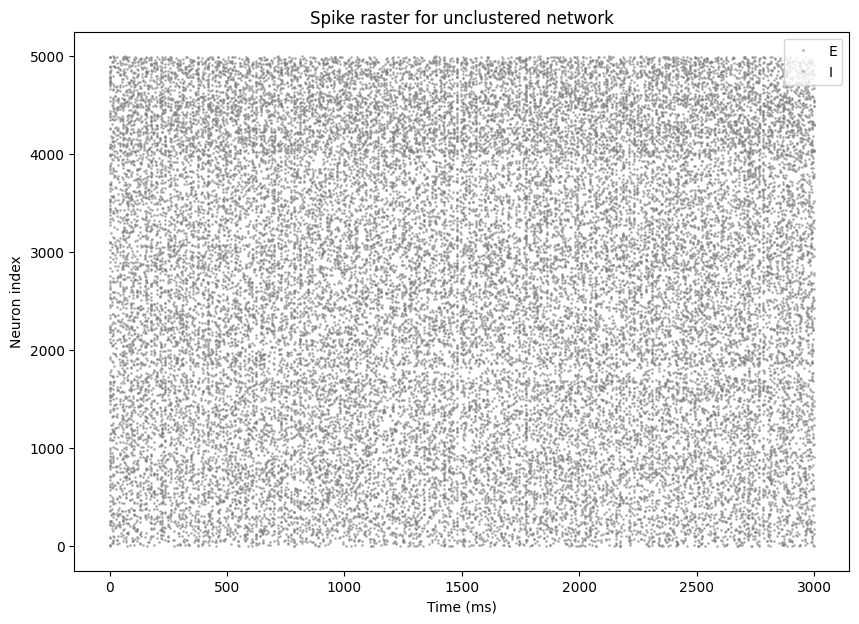

In [4]:
# Single raster plot
plot_spike_raster(
    unclustered_network.spike_monitor_e,
    unclustered_network.spike_monitor_i,
    n_e=params.N_E,
    title="Spike raster for unclustered network",
)
plt.show()

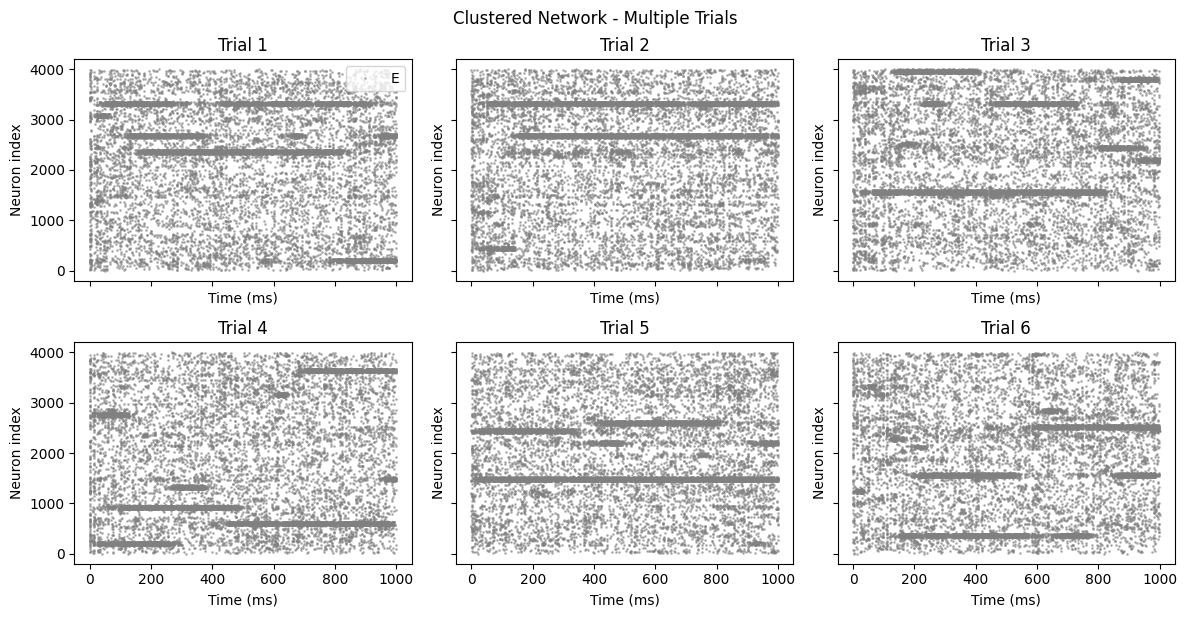

In [5]:
# Plot multiple trials in a grid
# Create a fresh network for the trial rasters
trial_network = NeuronNetwork(
    ModelParams(duration=1*second),  # Shorter duration for quick visualization
    ClusterParams(enabled=True, R_ee=2.5),
    seed=123
)

fig, axes = plot_trial_rasters(trial_network, n_trials=6, ncols=3, show_inhibitory=False)
fig.suptitle("Clustered Network - Multiple Trials", y=1.02)
plt.show()

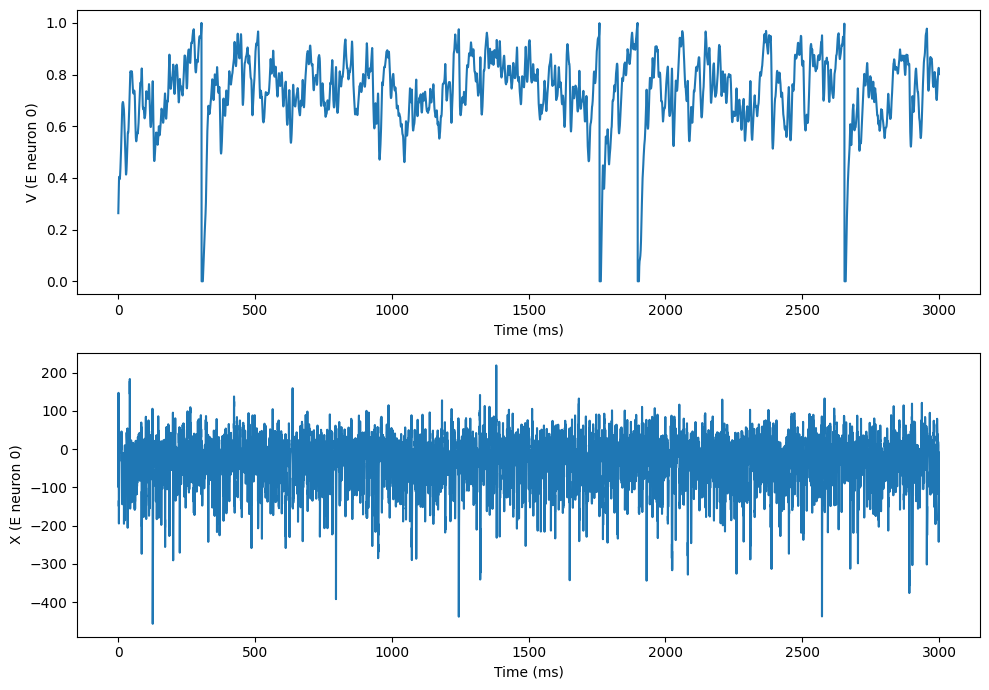

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(unclustered_network.state_monitor_e.t/ms, unclustered_network.state_monitor_e.V[0])
axes[0].set_ylabel('V (E neuron 0)')
axes[0].set_xlabel('Time (ms)')

axes[1].plot(unclustered_network.state_monitor_e.t/ms, unclustered_network.state_monitor_e.x[0])
axes[1].set_ylabel('X (E neuron 0)')
axes[1].set_xlabel('Time (ms)')

plt.tight_layout()

# Run and plot a clustered network

In [8]:
params = ModelParams()
cluster_params = ClusterParams(enabled=True, R_ee=2.5)

clustered_network = NeuronNetwork(params, cluster_params)
clustered_network.run()

<Axes: title={'center': 'Spike raster'}, ylabel='Neuron index'>

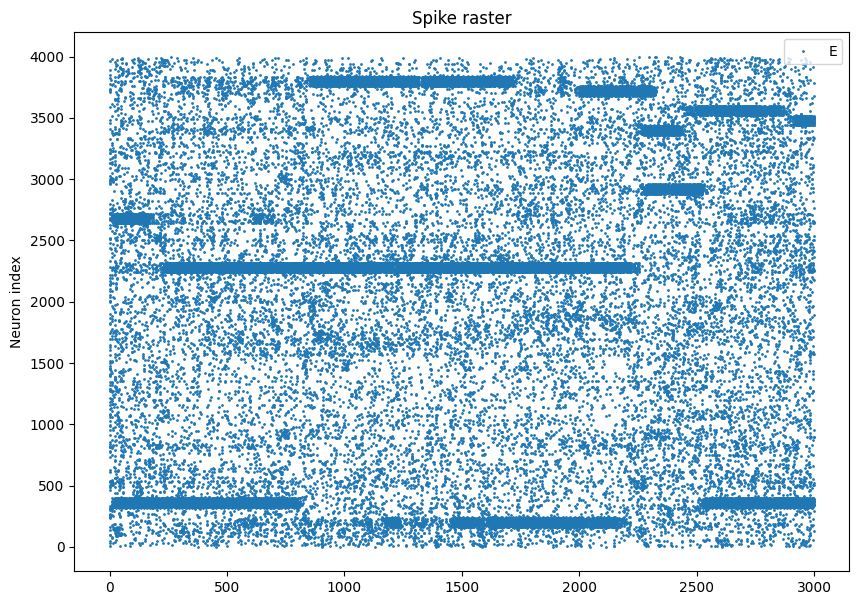

In [9]:
plot_spike_raster(clustered_network.spike_monitor_e)

## Plot the membrane potentials of a few neurons

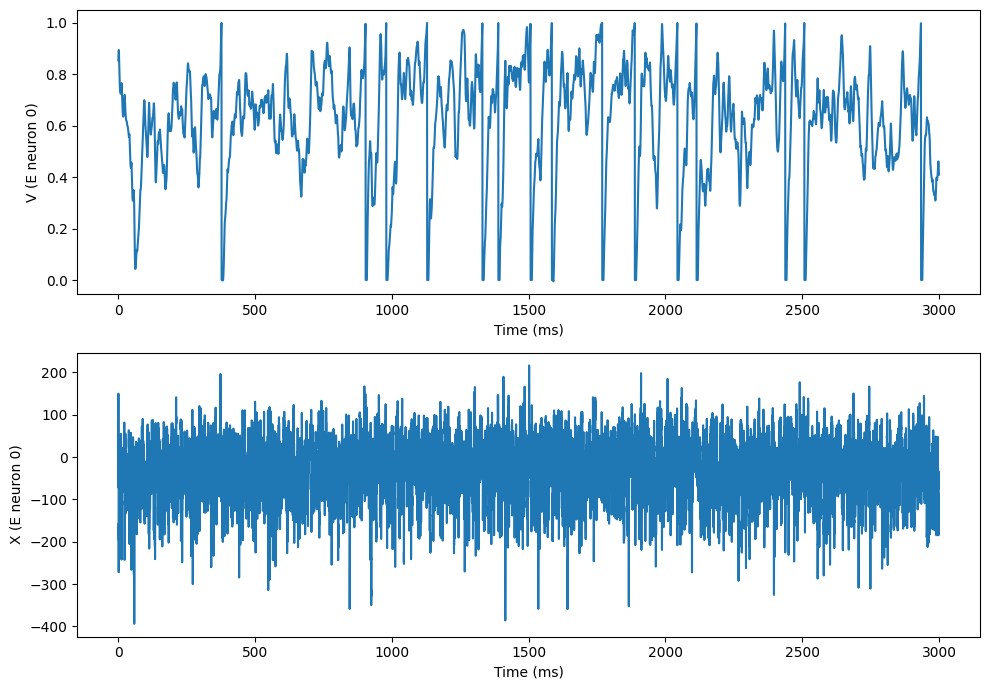

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(clustered_network.state_monitor_e.t/ms, clustered_network.state_monitor_e.V[0])
axes[0].set_ylabel('V (E neuron 0)')
axes[0].set_xlabel('Time (ms)')

axes[1].plot(clustered_network.state_monitor_e.t/ms, clustered_network.state_monitor_e.x[0])
axes[1].set_ylabel('X (E neuron 0)')
axes[1].set_xlabel('Time (ms)')

plt.tight_layout()
plt.show()

# Plotting the firing rate distribution

In [5]:
def plot_firing_rate_distribution(networks, labels, title, params):
    """Plot firing rate distribution for multiple networks."""
    fig, ax = plt.subplots()
    
    colors = {'Unclustered': 'black', 'Clustered': 'limegreen', 
              'Uniform': 'black'}

    firing_rates_by_label = {}
    for network, label in zip(networks, labels):
        firing_rates_e = firing_rate(
            network.spike_monitor_e,
            params.N_E,
            params.analysis_start_t,
            params.analysis_window_t,
        )
        firing_rates_i = firing_rate(
            network.spike_monitor_i,
            params.N_I,
            params.analysis_start_t,
            params.analysis_window_t,
        )
        print(firing_rates_e.shape, firing_rates_i.shape)

        rates = np.concatenate([firing_rates_e, firing_rates_i])
        print(rates.shape)

        firing_rates_by_label[label] = rates
        ax.hist(
            rates,
            bins=40,
            range=(0, 15),
            histtype='step',
            linewidth=2,
            color=colors.get(label, 'black'),
            label=label,
        )

    ax.set_xlabel('Firing Rate (Hz)')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend()

    return firing_rates_by_label

firing_rates_by_label = plot_firing_rate_distribution(
    [unclustered_network, clustered_network],
    ["Unclustered", "Clustered"],
    title="Firing Rate Distribution",
    params=params,
)

NameError: name 'clustered_network' is not defined

# Checking difference of exponential filter to an ODE

In [12]:
# TODO
# def x_prime(x, t1):
#     return -x / t1

# def g_prime(g, x, t2):
#     return (x - g) / t2

# def filter(t, t1, t2):
#     return 1 / (t2 - t1) * (np.exp(-t / t2) - np.exp(-t / t1))

# def euler_solve(x0, t, t1):
#     """Simple Euler method for x' = -x/t1."""
#     x = np.zeros_like(t)
#     x[0] = x0
#     dt = t[1] - t[0]
#     for i in range(1, len(t)):
#         x[i] = x[i - 1] + dt * x_prime(x[i - 1], t1)
#     return x

# t1 = 5.0
# x0 = 1.0
# t = np.linspace(0.0, 30.0, 600)

# x_num = euler_solve(x0, t, t1)

# sol = solve_ivp(
#     lambda tau, y: x_prime(y, t1),
#     t_span=(t[0], t[-1]),
#     y0=[x0],
#     t_eval=t,
# )
# x_scipy = sol.y[0]

# x_exact = x0 * np.exp(-t / t1)

# fig, ax = plt.subplots()
# ax.plot(t, x_num, label="Euler (numerical)")
# ax.plot(t, x_scipy, label="SciPy solve_ivp")
# ax.plot(t, x_exact, "--", label="Exact")
# ax.set_xlabel("t")
# ax.set_ylabel("x")
# ax.legend()
# plt.show()

# # Plot the filter for a sample t2.
# t2 = 2.0

# fig, ax = plt.subplots()
# ax.plot(t, filter(t, t1, t2), label="filter(t)")
# ax.set_xlabel("t")
# ax.set_ylabel("filter")
# ax.legend()
# plt.show()


    

# Experiment

Now instead of looking at a single network, we follow the paper's protocol of testing the uniform and clustered networks across 12 different network realizations, with 9 trials for each realization. This enables statistical analysis on spike counts.

## Metrics

**Firing Rate**: Spikes per neuron divided by the analysis window duration (Hz).

**Fano Factor**: Variance-to-mean ratio of spike counts across trials. A Poisson process has FF=1; values >1 indicate higher variability (bursty firing).

**Correlation Coefficient**: Spikes are binned into sliding time windows to create a spike count time series per neuron. We overlap the sliding time windows. The correlation coefficient between neuron pairs is: $\rho_{ij} = \text{Cov}(X_i, X_j) / (\sigma_i \sigma_j)$.

In [54]:
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
import json


@dataclass
class SpikeData:
    """Container for spike data from experiment runs."""
    uniform: list          # [realization][trial] = (spike_times, spike_ids)
    clustered: list        # [realization][trial] = (spike_times, spike_ids)
    model_params: ModelParams
    cluster_params: ClusterParams
    realizations: int
    trials: int

    def save(self, base_dir="data"):
        """Save spike data to disk as .npz files.

        Creates a directory at base_dir/experiment_run_{YYYY-MM-DD_HH-MM-SS}/
        containing one .npz file per network type with all spike data, plus
        a params.json metadata file.
        """
        timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        run_dir = Path(base_dir) / f"experiment_run_{timestamp}"
        run_dir.mkdir(parents=True, exist_ok=True)

        # Save spike data for each network type
        for name, spikes_list in [("uniform", self.uniform), ("clustered", self.clustered)]:
            arrays = {}
            for r, trial_spikes in enumerate(spikes_list):
                for t, (times, ids) in enumerate(trial_spikes):
                    arrays[f"r{r}_t{t}_times"] = np.asarray(times)
                    arrays[f"r{r}_t{t}_ids"] = np.asarray(ids)
            np.savez_compressed(run_dir / f"{name}_spikes.npz", **arrays)

        # Save parameters as JSON
        mp = self.model_params
        params_dict = {
            "realizations": self.realizations,
            "trials": self.trials,
            "model_params": {
                "N_E": mp.N_E,
                "N_I": mp.N_I,
                "duration_s": float(mp.duration),
                "analysis_start_t_s": float(mp.analysis_start_t),
                "analysis_window_t_s": float(mp.analysis_window_t),
                "fano_factor_window_t_s": float(mp.fano_factor_window_t),
                "firing_rate_window_t_s": float(mp.firing_rate_window_t),
                "p_conn_e": mp.p_conn_e,
                "p_conn_i": mp.p_conn_i,
            },
            "cluster_params": {
                "enabled": self.cluster_params.enabled,
                "R_ee": self.cluster_params.R_ee,
                "cluster_size": self.cluster_params.cluster_size,
                "weight_scaling_factor": self.cluster_params.weight_scaling_factor,
            },
        }
        with open(run_dir / "params.json", "w") as f:
            json.dump(params_dict, f, indent=2)

        print(f"Saved experiment data to {run_dir}/")
        return run_dir


class Experiment:
    """Runs simulations and collects spike data."""
    
    def __init__(
        self,
        realizations=12,
        trials=9,
        model_params=ModelParams(),
        cluster_params=ClusterParams(enabled=True, R_ee=2.5),
        seed=42,
    ):
        self.realizations = realizations
        self.trials = trials
        self.model_params = model_params
        self.cluster_params = cluster_params
        self.seed = seed
        
        # Initialize networks
        self.uniform_networks = self._initialize_networks(
            ClusterParams(enabled=False, R_ee=1.0), "uniform"
        )
        self.clustered_networks = self._initialize_networks(
            cluster_params, "clustered"
        )

    def _initialize_networks(self, cluster_params, name):
        networks = []
        for r in range(self.realizations):
            network = NeuronNetwork(
                self.model_params, cluster_params, seed=self.seed + 1000 * r
            )
            print(f"Built {name} network {r + 1}/{self.realizations}")
            networks.append(network)
        return networks

    def run(self) -> SpikeData:
        """Run all simulations and return spike data."""
        uniform_spikes = self._run_networks(self.uniform_networks, "uniform")
        clustered_spikes = self._run_networks(self.clustered_networks, "clustered")
        
        spike_data = SpikeData(
            uniform=uniform_spikes,
            clustered=clustered_spikes,
            model_params=self.model_params,
            cluster_params=self.cluster_params,
            realizations=self.realizations,
            trials=self.trials,
        )

        spike_data.save()
        return spike_data

    def _run_networks(self, networks, name):
        """Run networks and collect spike data."""
        print(f"Running {name} networks...")
        all_spikes = []
        
        for r, network in enumerate(networks):
            trial_spikes = []
            for t in range(self.trials):
                network.run()
                spike_times = np.array(network.spike_monitor_e.t)
                spike_ids = np.array(network.spike_monitor_e.i)
                trial_spikes.append((spike_times, spike_ids))
                print(f"  Realization {r + 1}/{len(networks)}, Trial {t + 1}/{self.trials}")
            all_spikes.append(trial_spikes)
        
        return all_spikes


# =============================================================================
# Standalone analysis functions
# =============================================================================

def _count_spikes_in_window(spike_times, spike_ids, n_neurons, start_t, end_t):
    """Count spikes per neuron in a time window."""
    mask = (spike_times >= start_t) & (spike_times < end_t)
    return np.bincount(spike_ids[mask], minlength=n_neurons)


def compute_fano_factor(spike_data: SpikeData, window_t=None):
    """Compute Fano factor from spike data.
    
    Args:
        spike_data: SpikeData object
        window_t: Analysis window duration (default: model_params.fano_factor_window_t)
    
    Returns:
        (uniform_ff, clustered_ff): Fano factors of shape (realizations, N_E)
    """
    params = spike_data.model_params
    start_t = float(params.analysis_start_t)
    window_t = float(window_t or params.fano_factor_window_t)
    end_t = start_t + window_t
    n_e = params.N_E
    
    def compute_ff(spikes_list):
        counts = np.zeros((spike_data.realizations, spike_data.trials, n_e), dtype=np.int32)
        for r, trial_spikes in enumerate(spikes_list):
            for t, (times, ids) in enumerate(trial_spikes):
                counts[r, t, :] = _count_spikes_in_window(times, ids, n_e, start_t, end_t)
        
        mean = counts.mean(axis=1)
        var = counts.var(axis=1, ddof=1)
        with np.errstate(divide="ignore", invalid="ignore"):
            return np.where(mean > 0, var / mean, np.nan)
    
    return compute_ff(spike_data.uniform), compute_ff(spike_data.clustered)


def compute_firing_rates(spike_data: SpikeData, window_t=None):
    """Compute firing rates from spike data.
    
    Args:
        spike_data: SpikeData object
        window_t: Analysis window duration (default: model_params.firing_rate_window_t)
    
    Returns:
        (uniform_rates, clustered_rates): Flattened arrays of firing rates
    """
    params = spike_data.model_params
    start_t = float(params.analysis_start_t)
    window_t = float(window_t or params.firing_rate_window_t)
    end_t = start_t + window_t
    n_e = params.N_E
    
    def compute_rates(spikes_list):
        rates = np.zeros((spike_data.realizations, spike_data.trials, n_e), dtype=np.float64)
        for r, trial_spikes in enumerate(spikes_list):
            for t, (times, ids) in enumerate(trial_spikes):
                counts = _count_spikes_in_window(times, ids, n_e, start_t, end_t)
                rates[r, t, :] = counts / window_t
        return rates.ravel()
    
    return compute_rates(spike_data.uniform), compute_rates(spike_data.clustered)


def _window_spikes_all_neurons(spike_times, spike_ids, n_neurons, window, step, timerange):
    """Compute spike counts in sliding windows for all neurons."""
    start_time, end_time = float(timerange[0]), float(timerange[1])
    window, step = float(window), float(step)
    
    window_starts = np.arange(start_time, end_time - window + step, step)
    n_windows = len(window_starts)
    
    window_counts = np.zeros((n_neurons, n_windows), dtype=np.int32)
    spike_times = np.asarray(spike_times)
    spike_ids = np.asarray(spike_ids)
    
    for w, ws in enumerate(window_starts):
        mask = (spike_times >= ws) & (spike_times <= ws + window)
        window_counts[:, w] = np.bincount(spike_ids[mask], minlength=n_neurons)
    
    return window_counts


def _compute_realization_correlation_data(
    trial_spikes,
    n_e,
    corr_window,
    corr_step,
    timerange,
    start_t_float,
    end_t_float,
):
    """Return trial-averaged covariance/variance and active-neuron mask for one realization."""
    n_trials = len(trial_spikes)
    if n_trials == 0:
        return None, None, None

    cov_sum = np.zeros((n_e, n_e), dtype=np.float64)
    var_sum = np.zeros(n_e, dtype=np.float64)
    spike_count_sum = np.zeros(n_e, dtype=np.int64)

    for times, ids in trial_spikes:
        times = np.asarray(times)
        ids = np.asarray(ids, dtype=np.int32)

        analysis_mask = (times >= start_t_float) & (times <= end_t_float)
        if np.any(analysis_mask):
            spike_count_sum += np.bincount(ids[analysis_mask], minlength=n_e)

        window_counts = _window_spikes_all_neurons(
            times, ids, n_e, corr_window, corr_step, timerange
        )
        cov_sum += np.cov(window_counts, rowvar=True, bias=False)
        var_sum += np.var(window_counts, axis=1, ddof=1)

    mean_cov = cov_sum / n_trials
    mean_var = var_sum / n_trials
    active_neurons = spike_count_sum > 0
    return mean_cov, mean_var, active_neurons


def _extract_correlation_coefficients_from_realization(
    mean_cov,
    mean_var,
    active_neurons,
    n_e,
    same_cluster_only=False,
    cluster_size=None,
    return_pairs=False,
):
    """Extract correlation coefficients for valid active-neuron pairs from one realization."""
    coeffs = []
    pair_i = []
    pair_j = []

    active_idx = np.flatnonzero(active_neurons)
    if len(active_idx) < 2:
        if return_pairs:
            return np.array([], dtype=np.float64), np.array([], dtype=np.int32), np.array([], dtype=np.int32)
        return np.array([], dtype=np.float64)

    if same_cluster_only and cluster_size is not None:
        for idx_i, i in enumerate(active_idx[:-1]):
            cluster_end = min((i // cluster_size + 1) * cluster_size, n_e)
            for j in active_idx[idx_i + 1:]:
                if j >= cluster_end:
                    break
                denom = np.sqrt(mean_var[i] * mean_var[j])
                if denom > 0:
                    coeffs.append(mean_cov[i, j] / denom)
                    if return_pairs:
                        pair_i.append(i)
                        pair_j.append(j)
    else:
        for idx_i, i in enumerate(active_idx[:-1]):
            for j in active_idx[idx_i + 1:]:
                denom = np.sqrt(mean_var[i] * mean_var[j])
                if denom > 0:
                    coeffs.append(mean_cov[i, j] / denom)
                    if return_pairs:
                        pair_i.append(i)
                        pair_j.append(j)

    coeffs = np.array(coeffs, dtype=np.float64)
    if return_pairs:
        return coeffs, np.array(pair_i, dtype=np.int32), np.array(pair_j, dtype=np.int32)
    return coeffs


def _get_realization_pair_coefficients(
    trial_spikes,
    n_e,
    corr_window,
    corr_step,
    timerange,
    start_t_float,
    end_t_float,
    same_cluster_only=False,
    cluster_size=None,
    return_pairs=False,
):
    """Shared realization-level correlation extraction used by plotting and analysis."""
    mean_cov, mean_var, active_neurons = _compute_realization_correlation_data(
        trial_spikes,
        n_e,
        corr_window,
        corr_step,
        timerange,
        start_t_float,
        end_t_float,
    )

    if mean_cov is None:
        if return_pairs:
            return np.array([], dtype=np.float64), np.array([], dtype=np.int32), np.array([], dtype=np.int32)
        return np.array([], dtype=np.float64)

    return _extract_correlation_coefficients_from_realization(
        mean_cov,
        mean_var,
        active_neurons,
        n_e,
        same_cluster_only=same_cluster_only,
        cluster_size=cluster_size,
        return_pairs=return_pairs,
    )


def compute_correlation_coefficients(spike_data: SpikeData, corr_window=50*ms,
                                      corr_step=25*ms, same_cluster_only=False):
    """Compute correlation coefficients from spike data.

    Args:
        spike_data: SpikeData object
        corr_window: Sliding window size for binning
        corr_step: Step size for sliding window
        same_cluster_only: If True, only compute for same-cluster pairs

    Returns:
        (uniform_coeffs, clustered_coeffs): Arrays of correlation coefficients

    Notes:
        Coefficients are computed per realization (averaging over that realization's trials)
        and concatenated, so neuron IDs are not pooled across different realizations.
        Neurons with zero spikes in the analysis window are excluded from pair calculations.
    """
    params = spike_data.model_params
    cluster_params = spike_data.cluster_params
    start_t = params.analysis_start_t
    end_t = start_t + params.analysis_window_t
    timerange = (start_t, end_t)
    n_e = params.N_E
    start_t_float = float(start_t)
    end_t_float = float(end_t)

    use_same_cluster = same_cluster_only and cluster_params.enabled
    cluster_size = cluster_params.cluster_size if use_same_cluster else None

    def compute_coeffs_by_realization(spikes_list):
        realization_coeffs = []
        for trial_spikes in spikes_list:
            coeffs = _get_realization_pair_coefficients(
                trial_spikes,
                n_e,
                corr_window,
                corr_step,
                timerange,
                start_t_float,
                end_t_float,
                same_cluster_only=use_same_cluster,
                cluster_size=cluster_size,
                return_pairs=False,
            )
            if coeffs.size > 0:
                realization_coeffs.append(coeffs)

        if realization_coeffs:
            return np.concatenate(realization_coeffs)
        return np.array([], dtype=np.float64)

    return (
        compute_coeffs_by_realization(spike_data.uniform),
        compute_coeffs_by_realization(spike_data.clustered),
    )


In [57]:
# =============================================================================
# Plotting functions for SpikeData analysis
# =============================================================================

def plot_firing_rate_distribution(spike_data: SpikeData, bins=20, rate_range=(0, 15), save_path=None):
    """Plot firing rate distribution for uniform and clustered networks."""
    uniform_rates, clustered_rates = compute_firing_rates(spike_data)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.hist(uniform_rates, bins=bins, histtype='step', linewidth=2, color='black', 
            range=rate_range, label=f'Uniform (mean={np.mean(uniform_rates):.2f} Hz)')
    ax.hist(clustered_rates, bins=bins, histtype='step', linewidth=2, color='limegreen', 
            range=rate_range, label=f'Clustered (mean={np.mean(clustered_rates):.2f} Hz)')
    
    ax.set_xlabel('Firing Rate (Hz)')
    ax.set_ylabel('Count')
    ax.set_title(f'Firing Rate Distribution (Excitatory Neurons)\n'
                 f'{spike_data.realizations} realizations × {spike_data.trials} trials')
    ax.legend()
    
    # Add triangle markers for means
    y_top = ax.get_ylim()[1]
    ax.plot([np.mean(uniform_rates)], [y_top * 1.01], marker='v', 
            markersize=6, color='black', clip_on=False)
    ax.plot([np.mean(clustered_rates)], [y_top * 1.01], marker='v', 
            markersize=6, color='limegreen', clip_on=False)
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, ax


def plot_fano_factor(spike_data: SpikeData, save_path=None):
    """Plot Fano factor distribution for uniform and clustered networks."""
    uniform_ff, clustered_ff = compute_fano_factor(spike_data)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    
    bins = np.linspace(0, 3, 35)
    uniform_mean = np.nanmean(uniform_ff)
    clustered_mean = np.nanmean(clustered_ff)
    
    ax.hist(uniform_ff.ravel(), bins=bins, histtype='step', linewidth=2, color='black', 
            label=f'Uniform (mean={uniform_mean:.3f})')
    ax.hist(clustered_ff.ravel(), bins=bins, histtype='step', linewidth=2, color='limegreen', 
            label=f'Clustered (mean={clustered_mean:.3f})')
    
    ax.set_xlabel('Fano Factor')
    ax.set_ylabel('Count')
    ax.legend()
    
    # Add triangle markers for means
    y_top = ax.get_ylim()[1]
    ax.plot([uniform_mean], [y_top * 1.01], marker='v', 
            markersize=6, color='black', clip_on=False)
    ax.plot([clustered_mean], [y_top * 1.01], marker='v', 
            markersize=6, color='limegreen', clip_on=False)
    
    print(f"Mean Fano Factor (Uniform): {uniform_mean:.3f}")
    print(f"Mean Fano Factor (Clustered): {clustered_mean:.3f}")
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, ax


def plot_correlation_all_pairs(spike_data: SpikeData, corr_windows=None, corr_step=25*ms, save_path=None):
    """Plot correlation coefficient distribution for all neuron pairs.
    
    Args:
        spike_data: SpikeData object
        corr_windows: List of window sizes to compare (default: [50*ms, 100*ms])
        corr_step: Step size for sliding window
        save_path: Path to save figure
    """
    if corr_windows is None:
        corr_windows = [50*ms, 100*ms]
    
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Colors for each window: (uniform_color, clustered_color)
    window_colors = [
        ('black', 'limegreen'),
        ('gray', 'dodgerblue'),
        ('darkred', 'orange'),
        ('purple', 'cyan'),
    ]
    
    bins = np.linspace(-0.5, 0.5, 50)
    
    for w_idx, corr_window in enumerate(corr_windows):
        window_ms = int(corr_window / ms)
        uniform_color, clustered_color = window_colors[w_idx % len(window_colors)]
        
        uniform_coeffs, clustered_coeffs = compute_correlation_coefficients(
            spike_data, corr_window, corr_step, same_cluster_only=False
        )
        
        ax.hist(uniform_coeffs, bins=bins, histtype='step', linewidth=2, 
                color=uniform_color, label=f'Uniform ({window_ms}ms)')
        ax.hist(clustered_coeffs, bins=bins, histtype='step', linewidth=2, 
                color=clustered_color, label=f'Clustered ({window_ms}ms)')
        
        print(f"Window {window_ms}ms (all pairs):")
        print(f"  Uniform: {np.nanmean(uniform_coeffs):.4f}, "
              f"Clustered: {np.nanmean(clustered_coeffs):.4f}")
    
    ax.set_xlabel('Correlation Coefficient')
    ax.set_ylabel('Count')
    ax.set_xlim(-0.5, 0.5)
    ax.legend()
    
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((6, 6))
    ax.yaxis.set_major_formatter(fmt)
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, ax


def plot_correlation_same_cluster(spike_data: SpikeData, corr_windows=None, corr_step=25*ms, save_path=None):
    """Plot correlation coefficient distribution for same-cluster neuron pairs.
    
    Args:
        spike_data: SpikeData object
        corr_windows: List of window sizes to compare (default: [50*ms, 100*ms])
        corr_step: Step size for sliding window
        save_path: Path to save figure
    """
    if corr_windows is None:
        corr_windows = [50*ms, 100*ms]
    
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Colors for each window: (uniform_color, clustered_color)
    window_colors = [
        ('black', 'limegreen'),
        ('gray', 'dodgerblue'),
        ('darkred', 'orange'),
        ('purple', 'cyan'),
    ]
    
    bins = np.linspace(-0.5, 1.0, 50)
    
    for w_idx, corr_window in enumerate(corr_windows):
        window_ms = int(corr_window / ms)
        uniform_color, clustered_color = window_colors[w_idx % len(window_colors)]
        
        uniform_coeffs, clustered_coeffs = compute_correlation_coefficients(
            spike_data, corr_window, corr_step, same_cluster_only=True
        )
        
        ax.hist(uniform_coeffs, bins=bins, histtype='step', linewidth=2, 
                color=uniform_color, label=f'Uniform ({window_ms}ms)')
        ax.hist(clustered_coeffs, bins=bins, histtype='step', linewidth=2, 
                color=clustered_color, label=f'Clustered ({window_ms}ms)')
        
        print(f"Window {window_ms}ms (same cluster):")
        print(f"  Uniform: {np.nanmean(uniform_coeffs):.4f}, "
              f"Clustered: {np.nanmean(clustered_coeffs):.4f}")
    
    ax.set_xlabel('Correlation Coefficient')
    ax.set_ylabel('Count')
    ax.set_xlim(-0.5, 1.0)
    ax.set_ylim(0, 15e4)
    ax.legend()
    
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((4, 4))
    ax.yaxis.set_major_formatter(fmt)
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, ax


def plot_rasters_from_spike_data(spike_data: SpikeData, n_trials=4, ncols=2, 
                                  network_type='clustered', realization=0,
                                  color='gray', alpha=0.5, neuron_fraction=0.5,
                                  seed=42, save_path=None):
    """Plot spike rasters from stored SpikeData.
    
    Args:
        spike_data: SpikeData object containing spike times and IDs
        n_trials: Number of trials to plot
        ncols: Number of columns in the grid
        network_type: 'uniform' or 'clustered'
        realization: Which realization to plot (default: 0)
        color: Color for the dots
        alpha: Transparency for the dots
        neuron_fraction: Fraction of neurons to plot (default: 0.6 = 60%)
        seed: Random seed for neuron selection
        save_path: Path to save the figure
    
    Returns:
        (fig, axes): Matplotlib figure and axes
    """
    spikes_list = spike_data.clustered if network_type == 'clustered' else spike_data.uniform
    trial_spikes = spikes_list[realization]
    
    n_trials = min(n_trials, len(trial_spikes))
    nrows = int(np.ceil(n_trials / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), 
                             sharex=True, sharey=True)
    axes = np.atleast_2d(axes)
    
    # Get duration from model params for x-axis
    duration_ms = float(spike_data.model_params.duration / ms)
    n_e = spike_data.model_params.N_E
    
    # Select a random subset of neurons to plot
    rng = np.random.default_rng(seed)
    n_neurons_to_plot = int(n_e * neuron_fraction)
    selected_neurons = set(rng.choice(n_e, size=n_neurons_to_plot, replace=False))
    
    for trial in range(n_trials):
        row = trial // ncols
        col = trial % ncols
        ax = axes[row, col]
        
        spike_times, spike_ids = trial_spikes[trial]
        # Convert to ms if needed (spike_times are in seconds from brian2)
        times_ms = spike_times * 1000 if spike_times.max() < 100 else spike_times
        
        # Filter to only selected neurons
        mask = np.array([sid in selected_neurons for sid in spike_ids])
        times_ms = times_ms[mask]
        spike_ids = spike_ids[mask]
        
        ax.plot(times_ms, spike_ids, ".", markersize=2, color=color, alpha=alpha)
        ax.set_title(f"Trial {trial + 1}")
        ax.set_ylabel("Neuron index")
        ax.set_xlabel("Time (ms)")
        ax.set_xlim(0, duration_ms)
        ax.set_ylim(0, n_e)
    
    # Hide any unused subplots
    for idx in range(n_trials, nrows * ncols):
        row = idx // ncols
        col = idx % ncols
        axes[row, col].set_visible(False)
    
    title = f"{'Clustered' if network_type == 'clustered' else 'Uniform'} Network - Realization {realization + 1}"
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, axes


def plot_fano_vs_ree(R_ee_values, mean_fano_factors, save_path=None):
    """Plot Fano factor as a function of cluster strength R_ee.
    
    Args:
        R_ee_values: Array of R_ee values tested
        mean_fano_factors: Array of mean Fano factors for each R_ee
        save_path: Path to save figure (optional)
    
    Returns:
        (fig, ax): Matplotlib figure and axes
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.plot(R_ee_values, mean_fano_factors, 'o-', color='black', linewidth=2, markersize=6)
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Poisson (FF=1)')
    
    ax.set_xlabel('$R_{EE}$ (cluster strength)')
    ax.set_ylabel('Mean Fano Factor')
    ax.set_title('Fano Factor vs Cluster Strength')
    ax.legend()
    
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, ax

In [35]:
# Run experiment with fewer realizations/trials for testing
experiment = Experiment(
    realizations=3, 
    trials=9, 
    model_params=ModelParams(duration=3*second),
    cluster_params=ClusterParams(enabled=True, R_ee=2.5),
)
spike_data = experiment.run()

Built uniform network 1/3
Built uniform network 2/3
Built uniform network 3/3
Built clustered network 1/3
Built clustered network 2/3
Built clustered network 3/3
Running uniform networks...
  Realization 1/3, Trial 1/9
  Realization 1/3, Trial 2/9
  Realization 1/3, Trial 3/9
  Realization 1/3, Trial 4/9
  Realization 1/3, Trial 5/9
  Realization 1/3, Trial 6/9
  Realization 1/3, Trial 7/9
  Realization 1/3, Trial 8/9
  Realization 1/3, Trial 9/9
  Realization 2/3, Trial 1/9
  Realization 2/3, Trial 2/9
  Realization 2/3, Trial 3/9
  Realization 2/3, Trial 4/9
  Realization 2/3, Trial 5/9
  Realization 2/3, Trial 6/9
  Realization 2/3, Trial 7/9
  Realization 2/3, Trial 8/9
  Realization 2/3, Trial 9/9
  Realization 3/3, Trial 1/9
  Realization 3/3, Trial 2/9
  Realization 3/3, Trial 3/9
  Realization 3/3, Trial 4/9
  Realization 3/3, Trial 5/9
  Realization 3/3, Trial 6/9
  Realization 3/3, Trial 7/9
  Realization 3/3, Trial 8/9
  Realization 3/3, Trial 9/9
Running clustered networks.

In [ ]:
# Alternative: load spike_data from disk (instead of running the experiment above)
from pathlib import Path
import json
import numpy as np


def load_spike_data_from_disk(run_dir=None, base_dir="data"):
    """Load SpikeData from a saved experiment directory in data/.

    Args:
        run_dir: folder name (e.g., "experiment_run_2026-02-06_17-01-11") or full path.
                 If None, the latest experiment_run_* folder in base_dir is used.
        base_dir: parent directory that stores experiment_run_* folders.

    Returns:
        (spike_data, run_path)
    """
    base_path = Path(base_dir)

    if run_dir is None:
        runs = sorted([p for p in base_path.glob("experiment_run_*") if p.is_dir()])
        if not runs:
            raise FileNotFoundError(f"No experiment_run_* folders found in {base_path}")
        run_path = runs[-1]
    else:
        run_path = Path(run_dir)
        if not run_path.exists():
            run_path = base_path / run_dir
        if not run_path.exists():
            raise FileNotFoundError(f"Could not find run directory: {run_dir}")

    params = json.loads((run_path / "params.json").read_text())
    model = params["model_params"]
    cluster = params["cluster_params"]

    model_params = ModelParams(
        N_E=model["N_E"],
        N_I=model["N_I"],
        duration=model["duration_s"] * second,
        analysis_start_t=model["analysis_start_t_s"] * second,
        analysis_window_t=model["analysis_window_t_s"] * second,
        fano_factor_window_t=model["fano_factor_window_t_s"] * second,
        firing_rate_window_t=model["firing_rate_window_t_s"] * second,
        p_conn_e=model["p_conn_e"],
        p_conn_i=model["p_conn_i"],
    )

    cluster_params = ClusterParams(
        enabled=cluster["enabled"],
        R_ee=cluster["R_ee"],
        cluster_size=cluster["cluster_size"],
        weight_scaling_factor=cluster["weight_scaling_factor"],
    )

    realizations = params["realizations"]
    trials = params["trials"]

    def _load_network_spikes(network_name):
        npz = np.load(run_path / f"{network_name}_spikes.npz")
        spikes = [[None for _ in range(trials)] for _ in range(realizations)]

        for r in range(realizations):
            for t in range(trials):
                times_key = f"r{r}_t{t}_times"
                ids_key = f"r{r}_t{t}_ids"
                if times_key not in npz or ids_key not in npz:
                    raise KeyError(f"Missing keys {times_key}/{ids_key} in {network_name}_spikes.npz")
                spikes[r][t] = (np.asarray(npz[times_key]), np.asarray(npz[ids_key], dtype=np.int32))

        return spikes

    spike_data = SpikeData(
        uniform=_load_network_spikes("uniform"),
        clustered=_load_network_spikes("clustered"),
        model_params=model_params,
        cluster_params=cluster_params,
        realizations=realizations,
        trials=trials,
    )

    print(f"Loaded spike_data from: {run_path}")
    print(f"  realizations={spike_data.realizations}, trials={spike_data.trials}, N_E={spike_data.model_params.N_E}")
    return spike_data, run_path


# Example usage (uncomment one):
# spike_data, loaded_run_path = load_spike_data_from_disk()  # latest run in data/
# spike_data, loaded_run_path = load_spike_data_from_disk("experiment_run_2026-02-07_14-10-22")


Loaded spike_data from: data/experiment_run_2026-02-07_14-10-22
  realizations=5, trials=9, N_E=4000


Mean Fano Factor (Uniform): 0.848
Mean Fano Factor (Clustered): 1.688


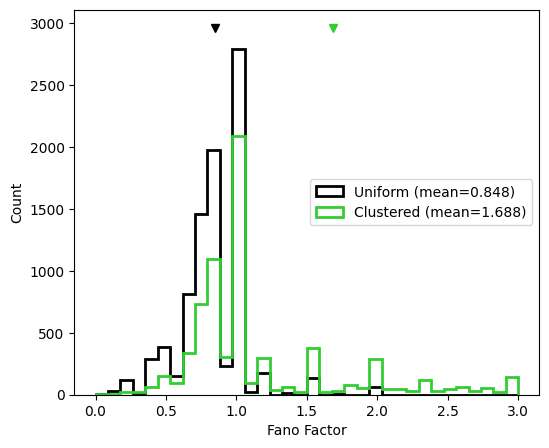

In [38]:
plot_fano_factor(spike_data)
plt.show()

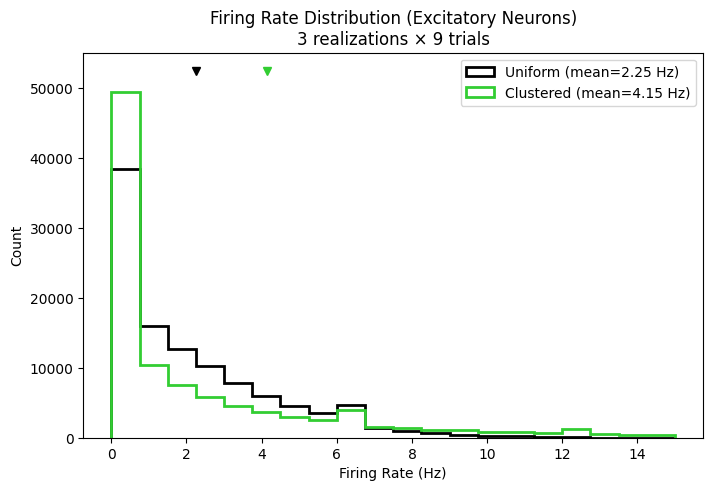

In [39]:
plot_firing_rate_distribution(spike_data)
plt.show()

Window 50ms (all pairs):
  Uniform: 0.0005, Clustered: 0.0017
Window 100ms (all pairs):
  Uniform: 0.0004, Clustered: 0.0021


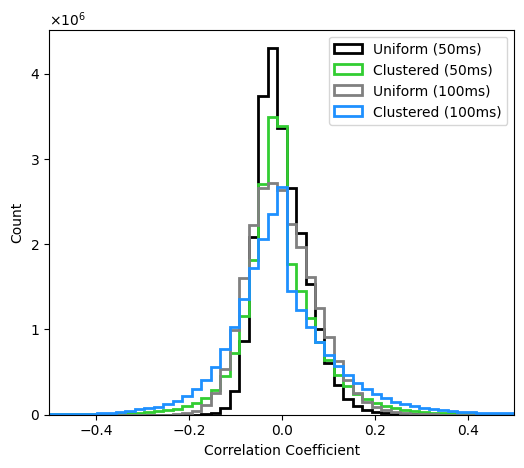

Window 50ms (same cluster):
  Uniform: 0.0004, Clustered: 0.3208
Window 100ms (same cluster):
  Uniform: 0.0004, Clustered: 0.3728


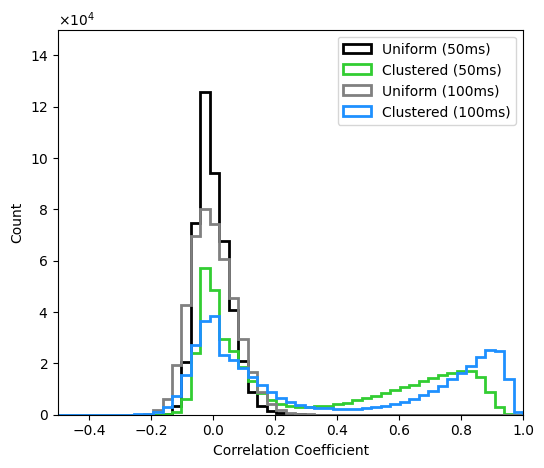

In [58]:
plot_correlation_all_pairs(spike_data)
plt.show()

plot_correlation_same_cluster(spike_data)
plt.show()

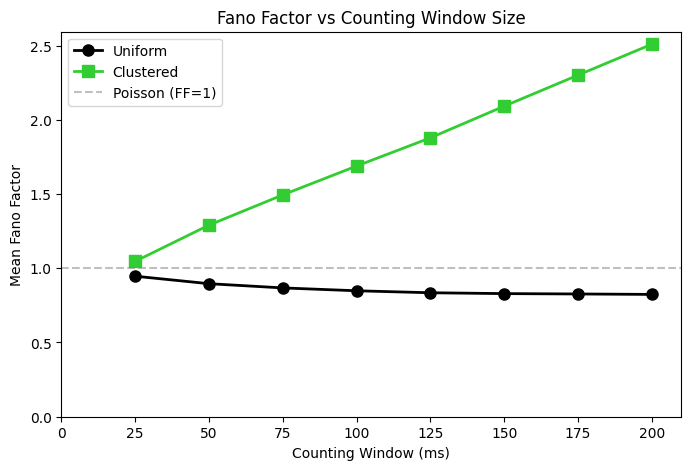

In [41]:
def plot_fano_vs_window(spike_data: SpikeData, window_times_ms=None, save_path=None):
    """Plot Fano factor as a function of analysis window size."""
    if window_times_ms is None:
        window_times_ms = [25, 50, 75, 100, 125, 150, 175, 200]
    
    uniform_ffs = []
    clustered_ffs = []

    for window_ms in window_times_ms:
        window_t = window_ms / 1000.0
        uniform_ff, clustered_ff = compute_fano_factor(spike_data, window_t=window_t)
        uniform_ffs.append(np.nanmean(uniform_ff))
        clustered_ffs.append(np.nanmean(clustered_ff))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(window_times_ms, uniform_ffs, 'o-', color='black', linewidth=2, markersize=8, label='Uniform')
    ax.plot(window_times_ms, clustered_ffs, 's-', color='limegreen', linewidth=2, markersize=8, label='Clustered')
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Poisson (FF=1)')
    ax.set_xlabel('Counting Window (ms)')
    ax.set_ylabel('Mean Fano Factor')
    ax.set_title('Fano Factor vs Counting Window Size')
    ax.legend()
    ax.set_xlim(0, max(window_times_ms) + 10)
    ax.set_ylim(0, None)
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, ax


plot_fano_vs_window(spike_data)
plt.show()

## Stimulus Experiment

In [13]:
def plot_stim_raster(stim):
    fig, (ax_r, ax_s) = plt.subplots(
            2, 1, sharex=True, figsize=(10, 6),
            gridspec_kw={"height_ratios": [4, 1], "hspace": 0.05}
        )
    
    ax_r.tick_params(labelbottom=False)
    intervals = [stim] if isinstance(stim, tuple) else stim
    for t0, t1 in intervals:
        ax_s.axvspan(t0/ms, t1/ms, color="k", alpha=1)
    ax_s.set_ylabel("Stim")
    ax_s.set_yticks([])
    ax_s.set_xlabel("Time (ms)")
    return (ax_r, ax_s)

In [85]:
N_E = 4000
multipliers_2 = np.full((60), 2)
multipliers_1 = np.ones((N_E-60))
multipliers = np.hstack((multipliers_2, multipliers_1))
stimulus_time = (1.5*second,2.5*second)
params = ModelParams(stimulus_multipliers=multipliers, stimulus_time=stimulus_time)


In [ ]:
cluster_params = ClusterParams(enabled=True, R_ee=2.5)
clustered_network = NeuronNetwork(params, cluster_params)
clustered_network.run()

In [87]:
cluster_params = ClusterParams(enabled=False, R_ee=1.0)
unclustered_network = NeuronNetwork(params, cluster_params)
unclustered_network.run()

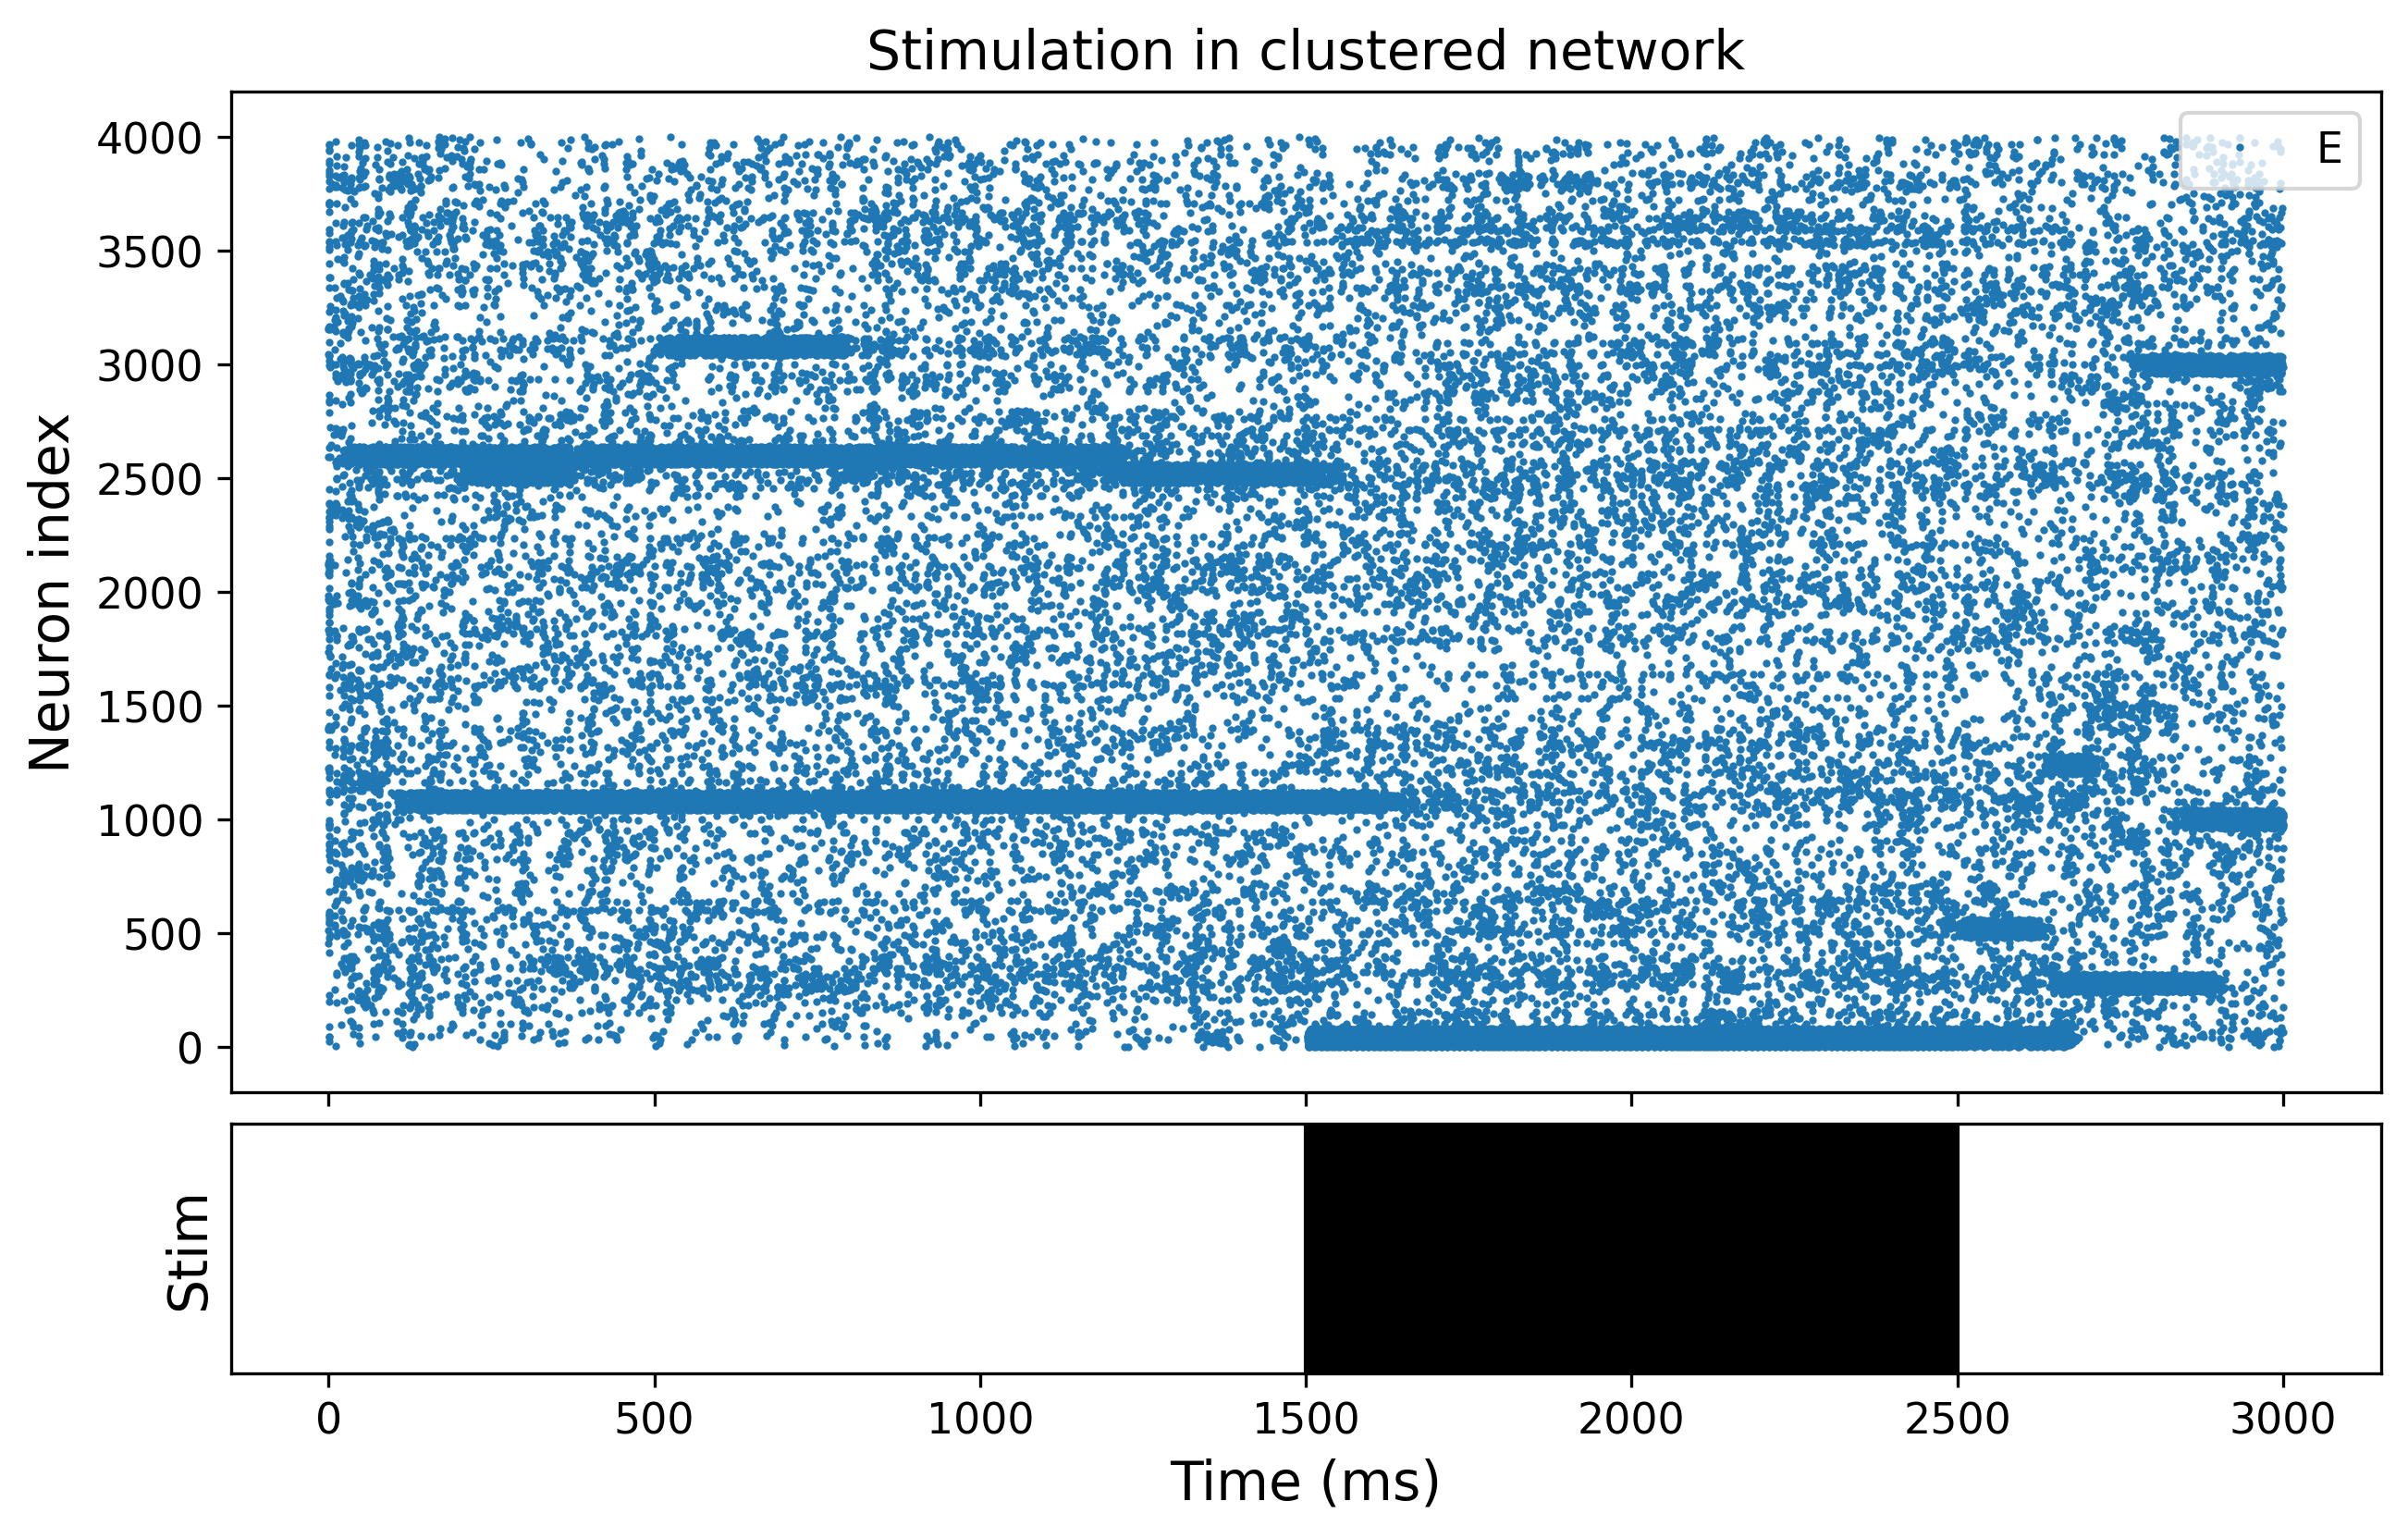

In [88]:
axes = plot_stim_raster(stimulus_time)
plot_spike_raster(
    clustered_network.spike_monitor_e,
    n_e=params.N_E,
    title="Stimulation in clustered network",
    ax=axes[0]
)
plt.show()

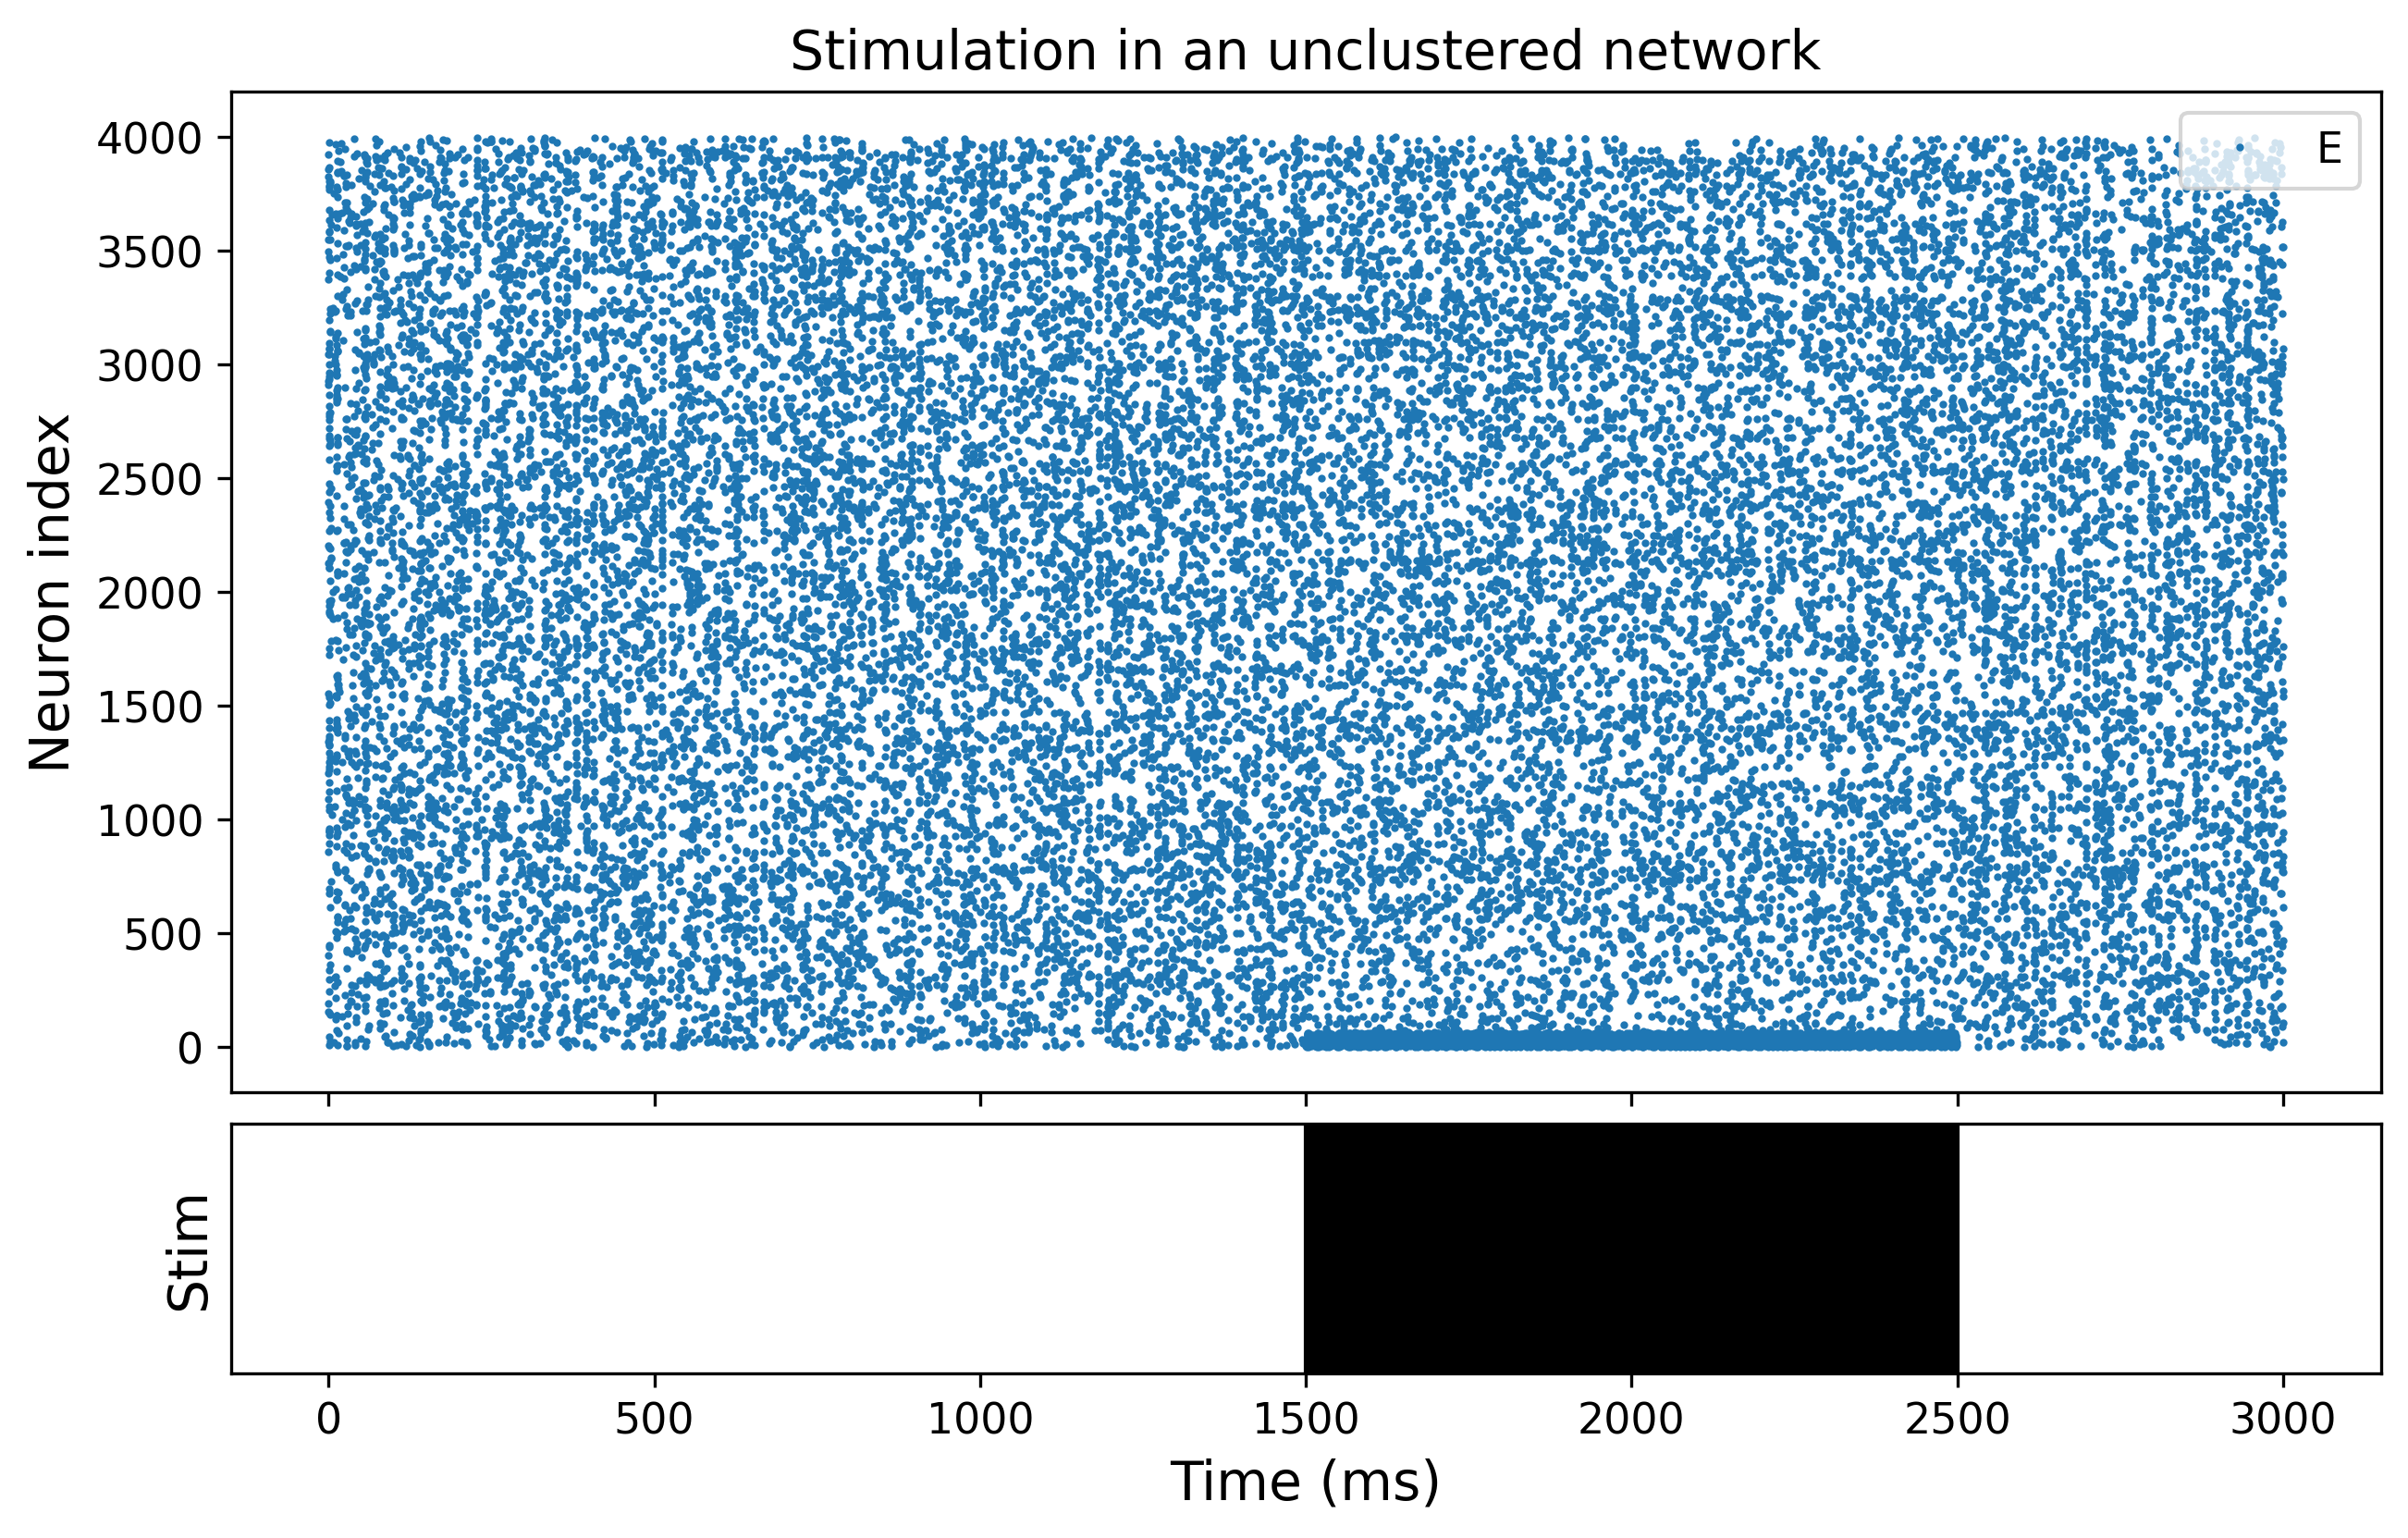

In [89]:
axes = plot_stim_raster(stimulus_time)
plot_spike_raster(
    unclustered_network.spike_monitor_e,
    n_e=params.N_E,
    title="Stimulation in an unclustered network",
    ax=axes[0]
)
plt.show()

# Comparing Fano Factor 

In [14]:
# =============================================================================
# Fano Factor vs R_ee Analysis
# =============================================================================

def compute_fano_factor_for_ree(R_ee_values, n_trials=3, duration=3*second, seed=42):
    """Compute mean Fano Factor for networks with different R_ee values."""
    mean_fano_factors = []
    model_params = ModelParams(duration=duration)
    
    for R_ee in R_ee_values:
        print(f"Running R_ee = {R_ee}...")
        
        cluster_params = ClusterParams(enabled=True, R_ee=R_ee)
        network = NeuronNetwork(model_params, cluster_params, seed=seed)
        
        # Collect spike data from trials
        trial_spikes = []
        for t in range(n_trials):
            network.run()
            spike_times = np.array(network.spike_monitor_e.t)
            spike_ids = np.array(network.spike_monitor_e.i)
            trial_spikes.append((spike_times, spike_ids))
        
        # Create SpikeData with only clustered data
        spike_data = SpikeData(
            uniform=[],  # Empty - not needed
            clustered=[trial_spikes],  # 1 realization
            model_params=model_params,
            cluster_params=cluster_params,
            realizations=1,
            trials=n_trials,
        )
        
        # Compute Fano factor (only use clustered result)
        _, clustered_ff = compute_fano_factor(spike_data)
        
        mean_ff = np.nanmean(clustered_ff)
        mean_fano_factors.append(mean_ff)
        print(f"  Mean Fano Factor: {mean_ff:.3f}")
    
    return np.array(mean_fano_factors)


# Run the analysis with finer R_ee resolution
R_ee_values = np.arange(1.0, 4.25, 0.25)
mean_fano_factors = compute_fano_factor_for_ree(R_ee_values, n_trials=9)


Running R_ee = 1.0...


KeyboardInterrupt: 

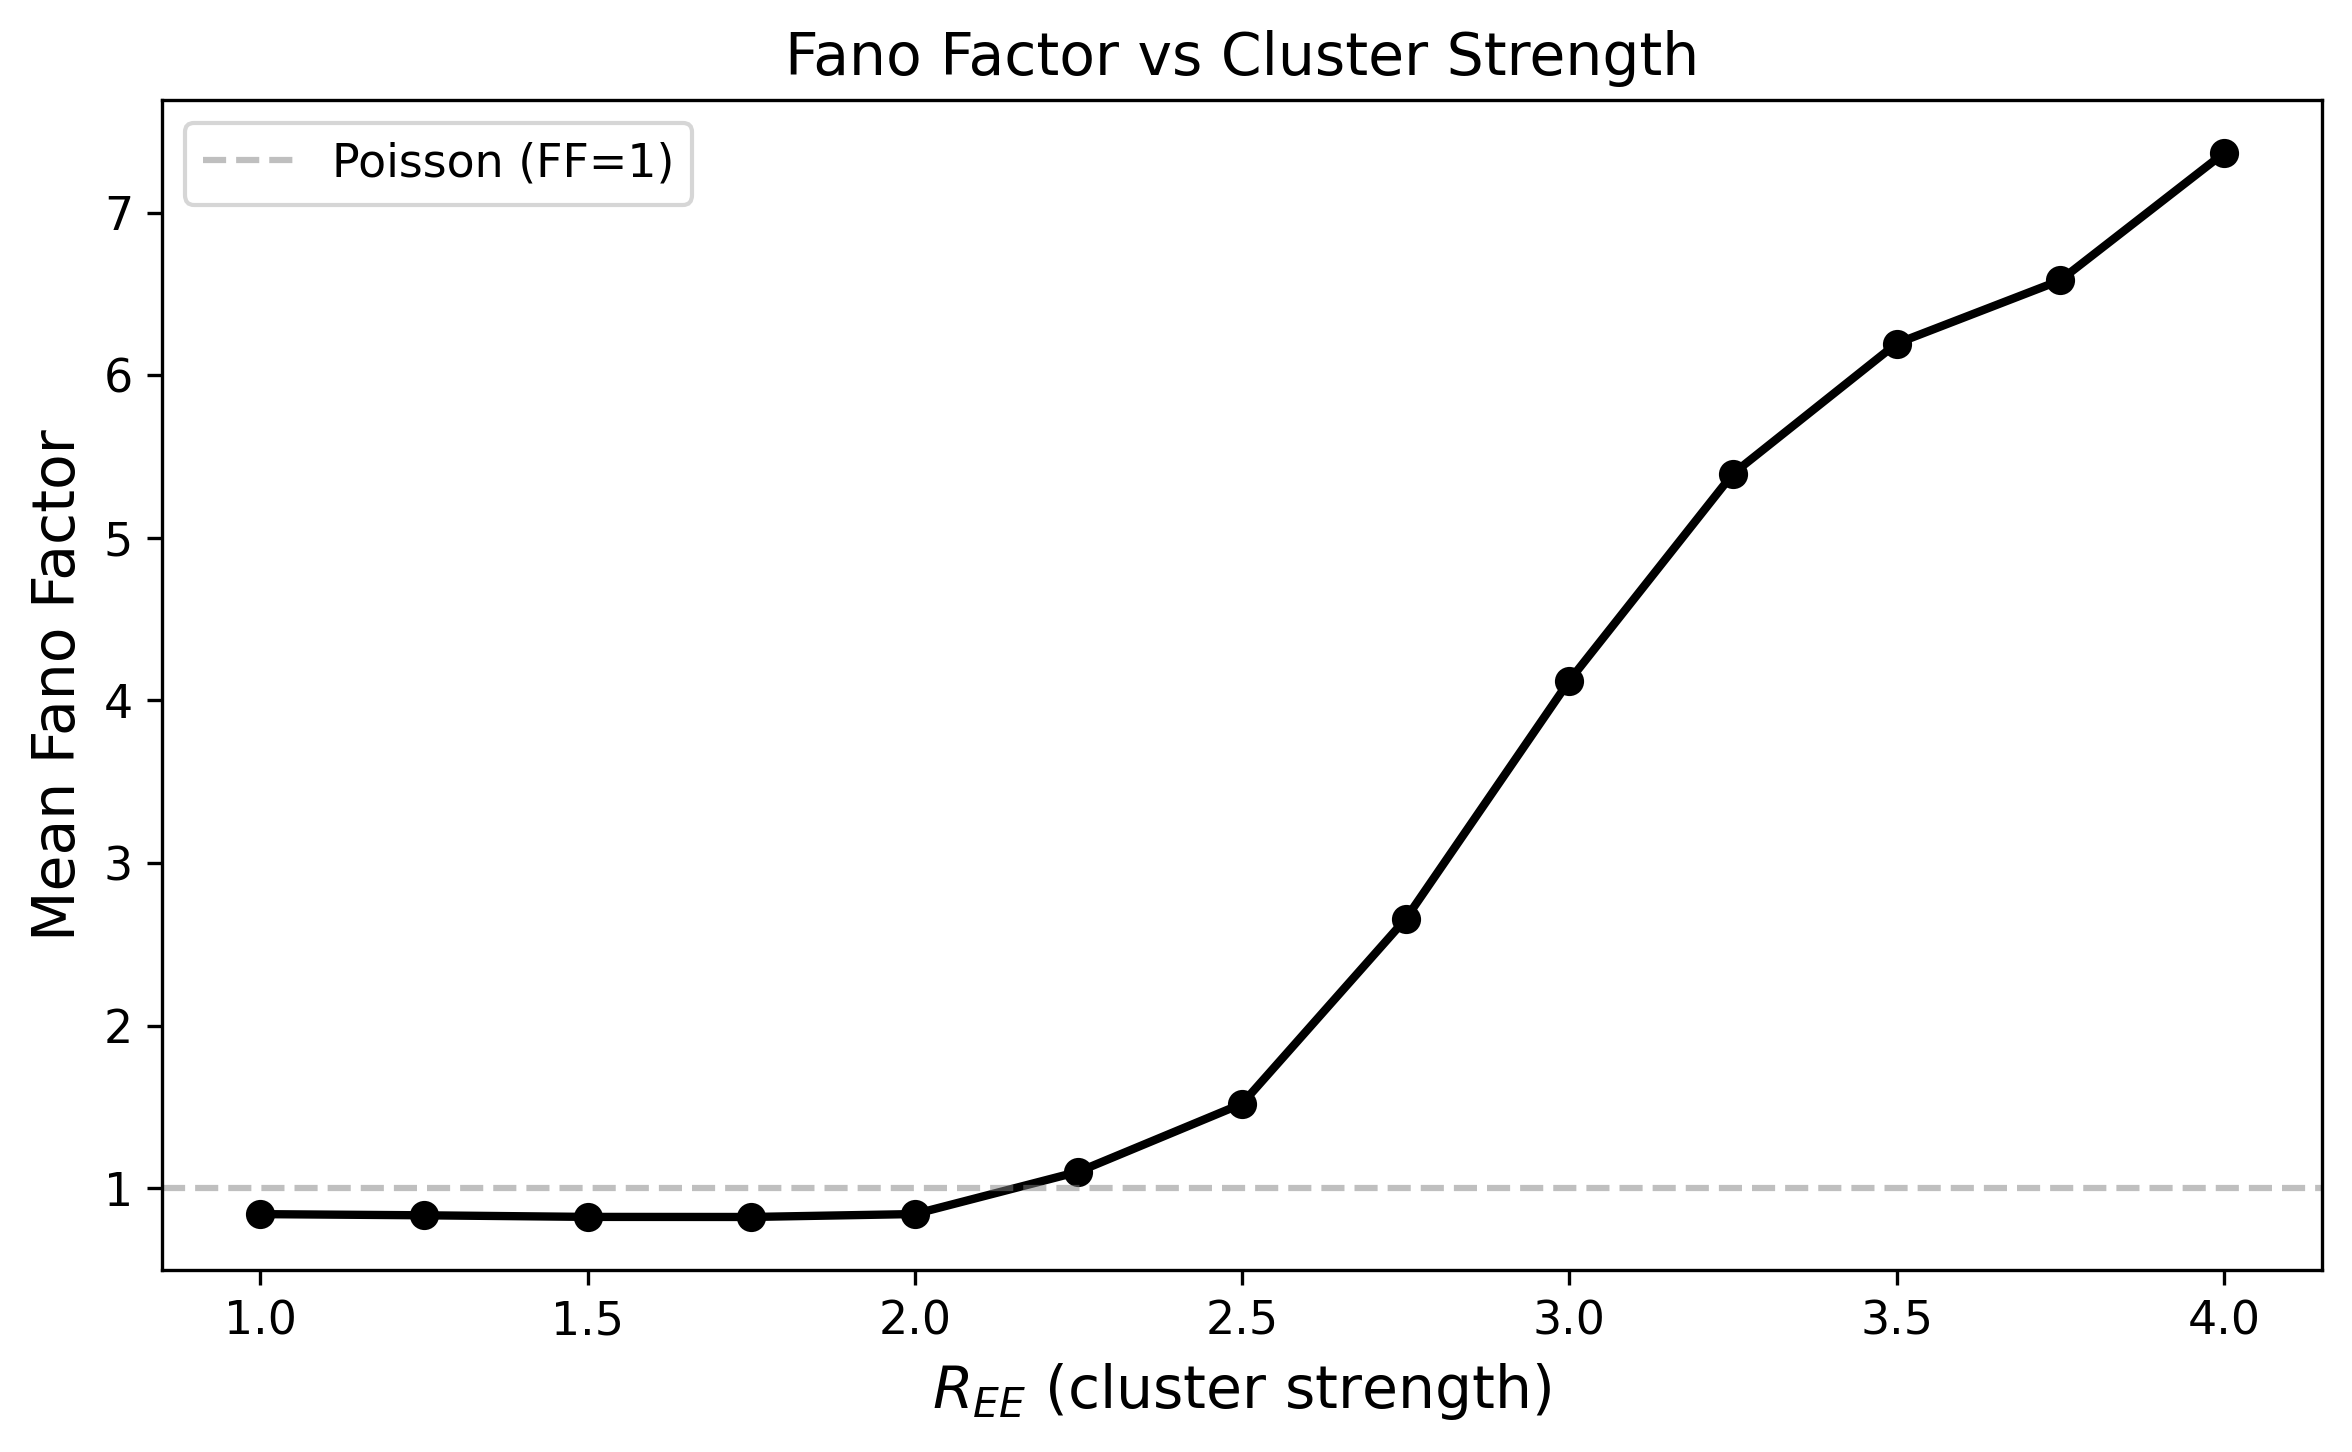

In [ ]:
plot_fano_vs_ree(R_ee_values, mean_fano_factors)
plt.show()

# Autocovariance and Cross Covariance

In [42]:
def _validate_max_lag(max_lag_bins, n_bins):
    if max_lag_bins < 0:
        raise ValueError(f"max_lag_bins must be >= 0, got {max_lag_bins}.")
    if n_bins < 1:
        raise ValueError(f"n_bins must be >= 1, got {n_bins}.")
    if max_lag_bins >= n_bins:
        raise ValueError(
            "max_lag_ms is too large for the chosen window/bin size; "
            f"need max_lag_bins < n_bins, got {max_lag_bins} >= {n_bins}."
        )


def _compute_bin_config(bin_size_ms, time_range_s, max_lag_ms):
    if bin_size_ms <= 0:
        raise ValueError(f"bin_size_ms must be > 0, got {bin_size_ms}.")
    if max_lag_ms < 0:
        raise ValueError(f"max_lag_ms must be >= 0, got {max_lag_ms}.")

    t0, t1 = map(float, time_range_s)
    if t1 <= t0:
        raise ValueError(f"time_range_s must satisfy end > start, got ({t0}, {t1}).")

    bin_size_s = bin_size_ms / 1000.0
    n_bins = int(np.floor((t1 - t0) / bin_size_s))
    if n_bins < 1:
        raise ValueError(
            "Window/binning produced zero bins; increase time_range_s or decrease bin_size_ms."
        )

    max_lag_bins = int(max_lag_ms / bin_size_ms)
    _validate_max_lag(max_lag_bins, n_bins)

    lags_ms = np.arange(-max_lag_bins, max_lag_bins + 1) * bin_size_ms
    return t0, t1, bin_size_s, n_bins, max_lag_bins, lags_ms


def _coerce_spike_arrays(times_s, ids):
    times_s = np.asarray(times_s, dtype=np.float64)
    ids = np.asarray(ids, dtype=np.int64)
    if times_s.shape[0] != ids.shape[0]:
        raise ValueError(
            f"times_s and ids must have same length, got {times_s.shape[0]} and {ids.shape[0]}."
        )
    return times_s, ids


def bin_spikes_to_counts(times_s, ids, n_neurons, bin_size_s, t_start_s, t_end_s):
    """
    Return spike COUNTS matrix of shape (n_neurons, n_bins) for [t_start_s, t_end_s).
    times_s: 1D array of spike times in seconds
    ids:     1D array of neuron indices (same length as times_s)
    """
    if n_neurons <= 0:
        raise ValueError(f"n_neurons must be > 0, got {n_neurons}.")
    if bin_size_s <= 0:
        raise ValueError(f"bin_size_s must be > 0, got {bin_size_s}.")
    if t_end_s <= t_start_s:
        raise ValueError(f"time window must satisfy t_end_s > t_start_s, got ({t_start_s}, {t_end_s}).")

    n_bins = int(np.floor((t_end_s - t_start_s) / bin_size_s))
    if n_bins < 1:
        raise ValueError(
            "Window/binning produced zero bins; increase time_range_s or decrease bin_size_ms."
        )

    counts = np.zeros((n_neurons, n_bins), dtype=np.int32)
    times_s, ids = _coerce_spike_arrays(times_s, ids)

    mask = (times_s >= t_start_s) & (times_s < t_end_s)
    if not np.any(mask):
        return counts

    times = times_s[mask]
    neurons = ids[mask]

    if np.any(neurons < 0) or np.any(neurons >= n_neurons):
        raise ValueError(
            f"ids out of range for n_neurons={n_neurons}: "
            f"min={int(neurons.min())}, max={int(neurons.max())}."
        )

    bin_idx = ((times - t_start_s) / bin_size_s).astype(np.int64)
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)
    np.add.at(counts, (neurons, bin_idx), 1)
    return counts


def counts_to_centered_rates(counts, bin_size_s):
    """
    counts: (n_neurons, n_bins)
    returns centered rate matrix X in Hz: X[i,t] = rate(i,t) - mean_rate(i)
    """
    if bin_size_s <= 0:
        raise ValueError(f"bin_size_s must be > 0, got {bin_size_s}.")

    counts = np.asarray(counts)
    if counts.ndim != 2:
        raise ValueError(f"counts must be 2D, got shape {counts.shape}.")

    rates = counts.astype(np.float64, copy=False) / bin_size_s
    rates -= rates.mean(axis=1, keepdims=True)
    return rates


# ----------------------------
# Covariance curves (fast, clear)
# ----------------------------

def mean_autocov_curve(X, max_lag_bins):
    """
    Mean spike-train autocovariance across neurons as a function of lag.
    X is centered per neuron, shape (n_neurons, n_bins), units Hz.
    Returns array length 2*max_lag_bins+1, lags [-max..+max].
    """
    X = np.asarray(X, dtype=np.float64)
    if X.ndim != 2:
        raise ValueError(f"X must be 2D, got shape {X.shape}.")

    _, n_bins = X.shape
    _validate_max_lag(max_lag_bins, n_bins)

    out = np.empty(2 * max_lag_bins + 1, dtype=np.float64)
    mid = max_lag_bins
    out[mid] = np.mean(X * X)

    for lag in range(1, max_lag_bins + 1):
        v = np.mean(X[:, :-lag] * X[:, lag:])
        out[mid + lag] = v
        out[mid - lag] = v

    return out


def mean_crosscov_curve(X, pairs, max_lag_bins):
    """
    Mean cross-covariance across a set of pairs as a function of lag.
    X is centered per neuron, shape (n_neurons, n_bins).
    pairs: array shape (P, 2) with i<j indices.
    Returns array length 2*max_lag_bins+1, lags [-max..+max].

    Convention:
      +lag uses X[i,t] * X[j,t+lag] averaged over t and pairs.
      -lag uses X[i,t+lag] * X[j,t].
    """
    X = np.asarray(X, dtype=np.float64)
    if X.ndim != 2:
        raise ValueError(f"X must be 2D, got shape {X.shape}.")

    n_neurons, n_bins = X.shape
    _validate_max_lag(max_lag_bins, n_bins)

    pairs = np.asarray(pairs, dtype=np.int64)
    if pairs.ndim != 2 or pairs.shape[1] != 2:
        raise ValueError(f"pairs must have shape (P, 2), got {pairs.shape}.")
    if pairs.shape[0] == 0:
        raise ValueError("pairs is empty; need at least one neuron pair to compute cross-covariance.")

    i = pairs[:, 0]
    j = pairs[:, 1]
    if np.any(i < 0) or np.any(i >= n_neurons) or np.any(j < 0) or np.any(j >= n_neurons):
        raise ValueError("pairs contains neuron indices outside [0, n_neurons).")

    out = np.empty(2 * max_lag_bins + 1, dtype=np.float64)
    mid = max_lag_bins
    out[mid] = np.mean(X[i, :] * X[j, :])

    for lag in range(1, max_lag_bins + 1):
        out[mid + lag] = np.mean(X[i, :-lag] * X[j, lag:])
        out[mid - lag] = np.mean(X[i, lag:] * X[j, :-lag])

    return out


# ----------------------------
# Pair sampling
# ----------------------------

def _effective_n_pairs(n_pairs, n_available):
    if n_pairs < 0:
        raise ValueError(f"n_pairs must be >= 0, got {n_pairs}.")
    return min(n_pairs, n_available)


def sample_pairs_uniform(n_neurons, n_pairs, rng):
    """Sample up to n_pairs unique unordered pairs (i<j) uniformly."""
    if n_neurons < 2:
        raise ValueError(f"n_neurons must be >= 2, got {n_neurons}.")

    n_available = n_neurons * (n_neurons - 1) // 2
    n_pairs_eff = _effective_n_pairs(n_pairs, n_available)
    if n_pairs_eff == 0:
        return np.empty((0, 2), dtype=np.int64)

    # Dense request: sample from full pair table exactly.
    if n_pairs_eff > n_available // 4:
        ii, jj = np.triu_indices(n_neurons, k=1)
        all_pairs = np.column_stack((ii, jj)).astype(np.int64, copy=False)
        if n_pairs_eff == n_available:
            return all_pairs
        chosen = rng.choice(n_available, size=n_pairs_eff, replace=False)
        return all_pairs[chosen]

    # Sparse request: rejection sampling avoids large pair tables.
    pairs = set()
    while len(pairs) < n_pairs_eff:
        a = int(rng.integers(0, n_neurons))
        b = int(rng.integers(0, n_neurons - 1))
        if b >= a:
            b += 1
        i, j = (a, b) if a < b else (b, a)
        pairs.add((i, j))

    return np.array(list(pairs), dtype=np.int64)


def sample_pairs_within_clusters(cluster_ids, n_pairs, rng):
    """
    Sample up to n_pairs unique unordered pairs (i<j) uniformly from within-cluster pairs.
    Works for equal or unequal cluster sizes.
    """
    cluster_ids = np.asarray(cluster_ids)
    if cluster_ids.ndim != 1:
        raise ValueError(f"cluster_ids must be 1D, got shape {cluster_ids.shape}.")

    clusters = {}
    for idx, cid in enumerate(cluster_ids):
        clusters.setdefault(int(cid), []).append(idx)

    members = [np.array(v, dtype=np.int64) for v in clusters.values() if len(v) >= 2]
    if not members:
        raise ValueError("No clusters with >=2 neurons; cannot sample within-cluster pairs.")

    pair_blocks = []
    for m in members:
        ii, jj = np.triu_indices(len(m), k=1)
        pair_blocks.append(np.column_stack((m[ii], m[jj])))

    all_pairs = np.vstack(pair_blocks).astype(np.int64, copy=False)
    n_pairs_eff = _effective_n_pairs(n_pairs, all_pairs.shape[0])
    if n_pairs_eff == 0:
        return np.empty((0, 2), dtype=np.int64)
    if n_pairs_eff == all_pairs.shape[0]:
        return all_pairs

    chosen = rng.choice(all_pairs.shape[0], size=n_pairs_eff, replace=False)
    return all_pairs[chosen]


def infer_cluster_ids(n_neurons, cluster_size):
    """Infer per-neuron cluster ids with the floor-division scheme used in network construction."""
    if n_neurons <= 0:
        raise ValueError(f"n_neurons must be > 0, got {n_neurons}.")
    if cluster_size <= 0:
        raise ValueError(f"cluster_size must be > 0, got {cluster_size}.")
    return np.arange(n_neurons, dtype=np.int64) // int(cluster_size)


# ----------------------------
# Full analysis: average over trials × realizations
# ----------------------------

def compute_covariance_condition(
    spikes_by_realization,
    n_neurons,
    bin_size_ms=2,
    time_range_s=(1.5, 3.0),
    max_lag_ms=200,
    within_cluster_pairs=False,
    cluster_ids=None,
    max_pairs=5000,
    seed=0,
    normalize_by_mean_rate=False,
):
    """
    spikes_by_realization: list of realizations; each realization is a list of trials;
                          each trial is (times_s, ids) arrays.
    Returns: lags_ms, mean_auto, mean_cross
    """
    if n_neurons < 2:
        raise ValueError(f"n_neurons must be >= 2, got {n_neurons}.")
    if max_pairs <= 0:
        raise ValueError(f"max_pairs must be > 0, got {max_pairs}.")

    t0, t1, bin_size_s, _, max_lag_bins, lags_ms = _compute_bin_config(
        bin_size_ms=bin_size_ms,
        time_range_s=time_range_s,
        max_lag_ms=max_lag_ms,
    )

    spikes_by_realization = list(spikes_by_realization)
    if len(spikes_by_realization) == 0:
        raise ValueError("spikes_by_realization is empty.")

    if within_cluster_pairs:
        if cluster_ids is None:
            raise ValueError("within_cluster_pairs=True requires cluster_ids.")
        cluster_ids = np.asarray(cluster_ids)
        if cluster_ids.shape[0] != n_neurons:
            raise ValueError(
                f"cluster_ids length must match n_neurons ({n_neurons}), got {cluster_ids.shape[0]}."
            )

    auto_sum = np.zeros(len(lags_ms), dtype=np.float64)
    cross_sum = np.zeros(len(lags_ms), dtype=np.float64)
    n_trials_total = 0

    for r, trials in enumerate(spikes_by_realization):
        trials = list(trials)
        if len(trials) == 0:
            continue

        rng = np.random.default_rng(seed + r)
        if within_cluster_pairs:
            pairs = sample_pairs_within_clusters(cluster_ids, max_pairs, rng)
        else:
            pairs = sample_pairs_uniform(n_neurons, max_pairs, rng)

        for times_s, ids in trials:
            counts = bin_spikes_to_counts(times_s, ids, n_neurons, bin_size_s, t0, t1)
            X = counts_to_centered_rates(counts, bin_size_s)

            auto = mean_autocov_curve(X, max_lag_bins)
            cross = mean_crosscov_curve(X, pairs, max_lag_bins)

            if normalize_by_mean_rate:
                mean_rate = counts.sum() / (n_neurons * (t1 - t0))
                if mean_rate > 0:
                    auto /= mean_rate
                    cross /= mean_rate

            auto_sum += auto
            cross_sum += cross
            n_trials_total += 1

    if n_trials_total == 0:
        raise ValueError("No trials found in spikes_by_realization.")

    return lags_ms, auto_sum / n_trials_total, cross_sum / n_trials_total


def compute_covariance_uniform_vs_clustered(
    uniform_spikes,
    clustered_spikes,
    n_neurons,
    cluster_ids=None,                 # required if clustered_within_cluster_pairs=True
    bin_size_ms=2,
    time_range_s=(1.5, 3.0),
    max_lag_ms=200,
    max_pairs=5000,
    seed=0,
    normalize_by_mean_rate=False,
    clustered_within_cluster_pairs=True,
):
    """
    Returns lags_ms and 4 curves: uniform_auto, uniform_cross, clustered_auto, clustered_cross.
    By default, clustered cross-covariance uses within-cluster pairs (paper Fig 2f logic).
    """
    lags_ms, u_auto, u_cross = compute_covariance_condition(
        uniform_spikes,
        n_neurons=n_neurons,
        bin_size_ms=bin_size_ms,
        time_range_s=time_range_s,
        max_lag_ms=max_lag_ms,
        within_cluster_pairs=False,
        cluster_ids=None,
        max_pairs=max_pairs,
        seed=seed,
        normalize_by_mean_rate=normalize_by_mean_rate,
    )

    _, c_auto, c_cross = compute_covariance_condition(
        clustered_spikes,
        n_neurons=n_neurons,
        bin_size_ms=bin_size_ms,
        time_range_s=time_range_s,
        max_lag_ms=max_lag_ms,
        within_cluster_pairs=clustered_within_cluster_pairs,
        cluster_ids=cluster_ids,
        max_pairs=max_pairs,
        seed=seed + 10_000,
        normalize_by_mean_rate=normalize_by_mean_rate,
    )

    return lags_ms, u_auto, u_cross, c_auto, c_cross


def compute_covariance_uniform_vs_clustered_from_spike_data(
    spike_data: SpikeData,
    bin_size_ms=2,
    time_range_s=None,
    max_lag_ms=200,
    max_pairs=5000,
    seed=0,
    normalize_by_mean_rate=False,
    clustered_within_cluster_pairs=True,
):
    """
    SpikeData-native convenience wrapper.

    Uses:
      - uniform spikes from spike_data.uniform
      - clustered spikes from spike_data.clustered
      - n_neurons from spike_data.model_params.N_E
      - default time_range_s from analysis_start_t to analysis_start_t + analysis_window_t
      - inferred cluster_ids from cluster_size when clustered_within_cluster_pairs=True
    """
    n_neurons = int(spike_data.model_params.N_E)

    if time_range_s is None:
        t0 = float(spike_data.model_params.analysis_start_t)
        t1 = float(spike_data.model_params.analysis_start_t + spike_data.model_params.analysis_window_t)
        time_range_s = (t0, t1)

    use_within_cluster_pairs = bool(
        clustered_within_cluster_pairs and getattr(spike_data.cluster_params, "enabled", False)
    )

    cluster_ids = None
    if use_within_cluster_pairs:
        cluster_size = int(spike_data.cluster_params.cluster_size)
        cluster_ids = infer_cluster_ids(n_neurons=n_neurons, cluster_size=cluster_size)

    return compute_covariance_uniform_vs_clustered(
        uniform_spikes=spike_data.uniform,
        clustered_spikes=spike_data.clustered,
        n_neurons=n_neurons,
        cluster_ids=cluster_ids,
        bin_size_ms=bin_size_ms,
        time_range_s=time_range_s,
        max_lag_ms=max_lag_ms,
        max_pairs=max_pairs,
        seed=seed,
        normalize_by_mean_rate=normalize_by_mean_rate,
        clustered_within_cluster_pairs=use_within_cluster_pairs,
    )



In [100]:
from pathlib import Path

def save_all_figures(spike_data: SpikeData, R_ee_values, mean_fano_factors,
                     output_dir="report/figures", dpi=300, format="pdf"):

    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Set matplotlib parameters for publication quality
    plt.rcParams.update({
        'font.size': 12,
        'axes.labelsize': 14,
        'axes.titlesize': 14,
        'legend.fontsize': 11,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'figure.dpi': dpi,
        'savefig.dpi': dpi,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1,
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
    })
    
    def save_figure(name, plot_func, *args, **kwargs):
        """Helper to save a single figure."""
        print(f"Saving {name.replace('_', ' ')}...")
        fig, _ = plot_func(*args, **kwargs)
        filepath = output_path / f"{name}.{format}"
        fig.savefig(filepath, dpi=dpi, bbox_inches='tight')
        plt.close(fig)
        return filepath
    
    figures = [
        ("firing_rate_distribution", plot_firing_rate_distribution, (spike_data,), {}),
        ("fano_factor_distribution", plot_fano_factor, (spike_data,), {}),
        ("correlation_all_pairs", plot_correlation_all_pairs, (spike_data,), {}),
        ("correlation_same_cluster", plot_correlation_same_cluster, (spike_data,), {}),
        ("fano_factor_vs_window", plot_fano_vs_window, (spike_data,), {}),
        ("fano_factor_vs_ree", plot_fano_vs_ree, (R_ee_values, mean_fano_factors), {}),
        ("rasters_uniform", plot_rasters_from_spike_data, (spike_data,), {'network_type': 'uniform'}),
        ("rasters_clustered", plot_rasters_from_spike_data, (spike_data,), {'network_type': 'clustered'}),
    ]
    
    saved_files = [save_figure(name, func, *args, **kwargs) for name, func, args, kwargs in figures]
    
    print(f"\nSaved {len(saved_files)} figures to '{output_dir}/':")
    for f in saved_files:
        print(f"  - {f.name}")
    
    return saved_files

save_all_figures(
    spike_data, 
    R_ee_values,
    mean_fano_factors,
    output_dir="report/figures",
    dpi=300,
    format="pdf"
)

Saving firing rate distribution...
Saving fano factor distribution...
Mean Fano Factor (Uniform): 0.854
Mean Fano Factor (Clustered): 1.852
Saving correlation all pairs...
Window 50ms (all pairs):
  Uniform: 0.0005, Clustered: 0.0008
Window 100ms (all pairs):
  Uniform: 0.0003, Clustered: 0.0009
Saving correlation same cluster...
Window 50ms (same cluster):
  Uniform: 0.0005, Clustered: 0.4111
Window 100ms (same cluster):
  Uniform: 0.0005, Clustered: 0.4985
Saving fano factor vs window...
Saving fano factor vs ree...
Saving rasters uniform...
Saving rasters clustered...

Saved 8 figures to 'report/figures/':
  - firing_rate_distribution.pdf
  - fano_factor_distribution.pdf
  - correlation_all_pairs.pdf
  - correlation_same_cluster.pdf
  - fano_factor_vs_window.pdf
  - fano_factor_vs_ree.pdf
  - rasters_uniform.pdf
  - rasters_clustered.pdf


[PosixPath('report/figures/firing_rate_distribution.pdf'),
 PosixPath('report/figures/fano_factor_distribution.pdf'),
 PosixPath('report/figures/correlation_all_pairs.pdf'),
 PosixPath('report/figures/correlation_same_cluster.pdf'),
 PosixPath('report/figures/fano_factor_vs_window.pdf'),
 PosixPath('report/figures/fano_factor_vs_ree.pdf'),
 PosixPath('report/figures/rasters_uniform.pdf'),
 PosixPath('report/figures/rasters_clustered.pdf')]

## Correlation Tail Diagnostics (Simple and Direct)

These cells explain why the correlation histogram has a long right tail in clustered networks.


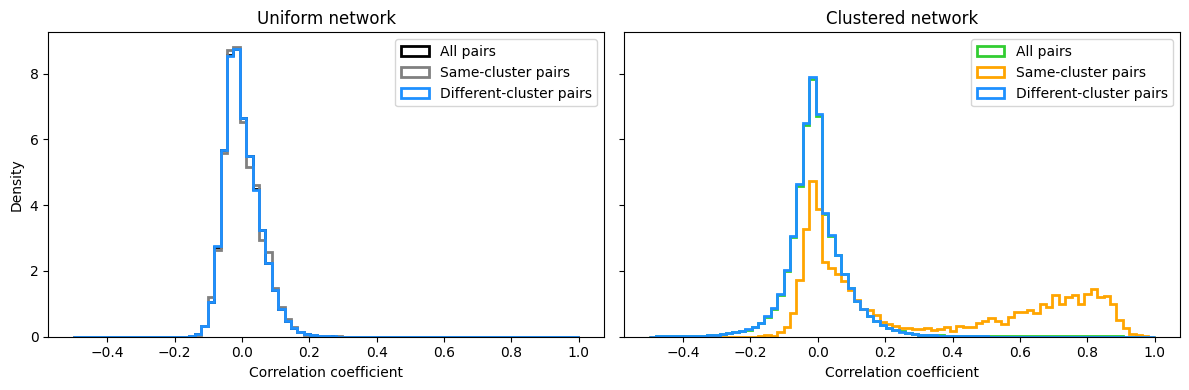


Summary (mean, q95, q99, p[r>0.2]):
Uniform   all  |  0.0005,  0.097,  0.150,  0.002
Uniform   same |  0.0009,  0.099,  0.148,  0.003
Uniform   diff |  0.0005,  0.097,  0.150,  0.002
Clustered all  |  0.0015,  0.159,  0.396,  0.032
Clustered same |  0.3219,  0.856,  0.898,  0.467
Clustered diff | -0.0050,  0.145,  0.259,  0.023

Same-cluster pair opportunities in full network: 158,000/7,998,000 (1.98%)

Tail composition in clustered network:
  r > 0.2: same-cluster share = 29.0% (3,243/11,195)
  r > 0.3: same-cluster share = 59.7% (3,037/5,090)
  r > 0.4: same-cluster share = 81.5% (2,867/3,518)
  r > 0.5: same-cluster share = 93.9% (2,629/2,801)


In [62]:
def _window_counts_subset(spike_times, spike_ids, n_e, neuron_ids, window, step, timerange):
    start_t, end_t = float(timerange[0]), float(timerange[1])
    window = float(window)
    step = float(step)
    starts = np.arange(start_t, end_t - window + step, step)

    counts = np.zeros((len(neuron_ids), len(starts)), dtype=np.float64)
    spike_times = np.asarray(spike_times)
    spike_ids = np.asarray(spike_ids, dtype=np.int32)

    interval = (spike_times >= start_t) & (spike_times <= end_t)
    spike_times = spike_times[interval]
    spike_ids = spike_ids[interval]

    for w, ws in enumerate(starts):
        mask = (spike_times >= ws) & (spike_times <= ws + window)
        if np.any(mask):
            b = np.bincount(spike_ids[mask], minlength=n_e)
            counts[:, w] = b[neuron_ids]

    return counts


def analyze_correlation_tail_simple(spike_data, subset_size=500, corr_window=50*ms, corr_step=25*ms, seed=0):
    params = spike_data.model_params
    cluster_size = spike_data.cluster_params.cluster_size
    n_e = params.N_E
    timerange = (params.analysis_start_t, params.analysis_start_t + params.analysis_window_t)

    rng = np.random.default_rng(seed)
    subset_size = min(subset_size, n_e)
    neuron_ids = np.sort(rng.choice(n_e, size=subset_size, replace=False))

    cluster_ids = neuron_ids // cluster_size
    pair_i, pair_j = np.triu_indices(subset_size, k=1)
    same_mask = cluster_ids[pair_i] == cluster_ids[pair_j]

    results = {}
    for name, spikes_list in [("Uniform", spike_data.uniform), ("Clustered", spike_data.clustered)]:
        all_vals, same_vals, diff_vals = [], [], []

        for trial_spikes in spikes_list:  # one realization
            cov_sum = np.zeros((subset_size, subset_size), dtype=np.float64)
            var_sum = np.zeros(subset_size, dtype=np.float64)
            spike_count_sum = np.zeros(subset_size, dtype=np.int64)
            n_trials = len(trial_spikes)

            for times, ids in trial_spikes:
                times = np.asarray(times)
                ids = np.asarray(ids, dtype=np.int32)

                interval_mask = (times >= float(timerange[0])) & (times <= float(timerange[1]))
                if np.any(interval_mask):
                    b = np.bincount(ids[interval_mask], minlength=n_e)
                    spike_count_sum += b[neuron_ids]

                x = _window_counts_subset(times, ids, n_e, neuron_ids, corr_window, corr_step, timerange)
                cov_sum += np.cov(x, rowvar=True, bias=False)
                var_sum += np.var(x, axis=1, ddof=1)

            mean_cov = cov_sum / n_trials
            mean_var = var_sum / n_trials
            active_local = spike_count_sum > 0

            denom = np.sqrt(mean_var[pair_i] * mean_var[pair_j])
            valid = (denom > 0) & active_local[pair_i] & active_local[pair_j]

            vals = mean_cov[pair_i[valid], pair_j[valid]] / denom[valid]
            same_valid = same_mask[valid]

            all_vals.append(vals)
            same_vals.append(vals[same_valid])
            diff_vals.append(vals[~same_valid])

        results[name] = {
            "all": np.concatenate(all_vals) if len(all_vals) else np.array([], dtype=np.float64),
            "same": np.concatenate(same_vals) if len(same_vals) else np.array([], dtype=np.float64),
            "diff": np.concatenate(diff_vals) if len(diff_vals) else np.array([], dtype=np.float64),
        }

    bins = np.linspace(-0.5, 1.0, 80)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    axes[0].hist(results["Uniform"]["all"], bins=bins, histtype="step", linewidth=2, color="black", density=True, label="All pairs")
    axes[0].hist(results["Uniform"]["same"], bins=bins, histtype="step", linewidth=2, color="gray", density=True, label="Same-cluster pairs")
    axes[0].hist(results["Uniform"]["diff"], bins=bins, histtype="step", linewidth=2, color="dodgerblue", density=True, label="Different-cluster pairs")
    axes[0].set_title("Uniform network")
    axes[0].set_xlabel("Correlation coefficient")
    axes[0].set_ylabel("Density")
    axes[0].legend()

    axes[1].hist(results["Clustered"]["all"], bins=bins, histtype="step", linewidth=2, color="limegreen", density=True, label="All pairs")
    axes[1].hist(results["Clustered"]["same"], bins=bins, histtype="step", linewidth=2, color="orange", density=True, label="Same-cluster pairs")
    axes[1].hist(results["Clustered"]["diff"], bins=bins, histtype="step", linewidth=2, color="dodgerblue", density=True, label="Different-cluster pairs")
    axes[1].set_title("Clustered network")
    axes[1].set_xlabel("Correlation coefficient")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    def brief_stats(x):
        if x.size == 0:
            return np.nan, np.nan, np.nan, np.nan
        return np.mean(x), np.quantile(x, 0.95), np.quantile(x, 0.99), np.mean(x > 0.2)

    print("")
    print("Summary (mean, q95, q99, p[r>0.2]):")
    for network in ["Uniform", "Clustered"]:
        for pair_type in ["all", "same", "diff"]:
            m, q95, q99, p02 = brief_stats(results[network][pair_type])
            print(f"{network:9s} {pair_type:4s} | {m: .4f}, {q95: .3f}, {q99: .3f}, {p02: .3f}")

    n_pairs_total = n_e * (n_e - 1) // 2
    n_clusters = n_e // cluster_size
    n_same_pairs = n_clusters * (cluster_size * (cluster_size - 1) // 2)
    print("")
    print(f"Same-cluster pair opportunities in full network: {n_same_pairs:,}/{n_pairs_total:,} ({n_same_pairs/n_pairs_total:.2%})")

    print("")
    print("Tail composition in clustered network:")
    for threshold in [0.2, 0.3, 0.4, 0.5]:
        all_count = np.sum(results["Clustered"]["all"] > threshold)
        same_count = np.sum(results["Clustered"]["same"] > threshold)
        frac_same = same_count / all_count if all_count > 0 else np.nan
        print(f"  r > {threshold:.1f}: same-cluster share = {frac_same:.1%} ({same_count:,}/{all_count:,})")

    return neuron_ids


tail_subset_neurons = analyze_correlation_tail_simple(spike_data, subset_size=500, seed=0)


Found 33968 trial-active pairs above threshold r >= 0.50; plotting 6 sampled pairs.
Filtered out 66949 pairs because at least one neuron had 0 spikes in plotted trial window.
Note: displayed r is realization-level (averaged across all trials in this realization).
A pair can have high realization-level r even if spikes are sparse/non-overlapping in the plotted trial.


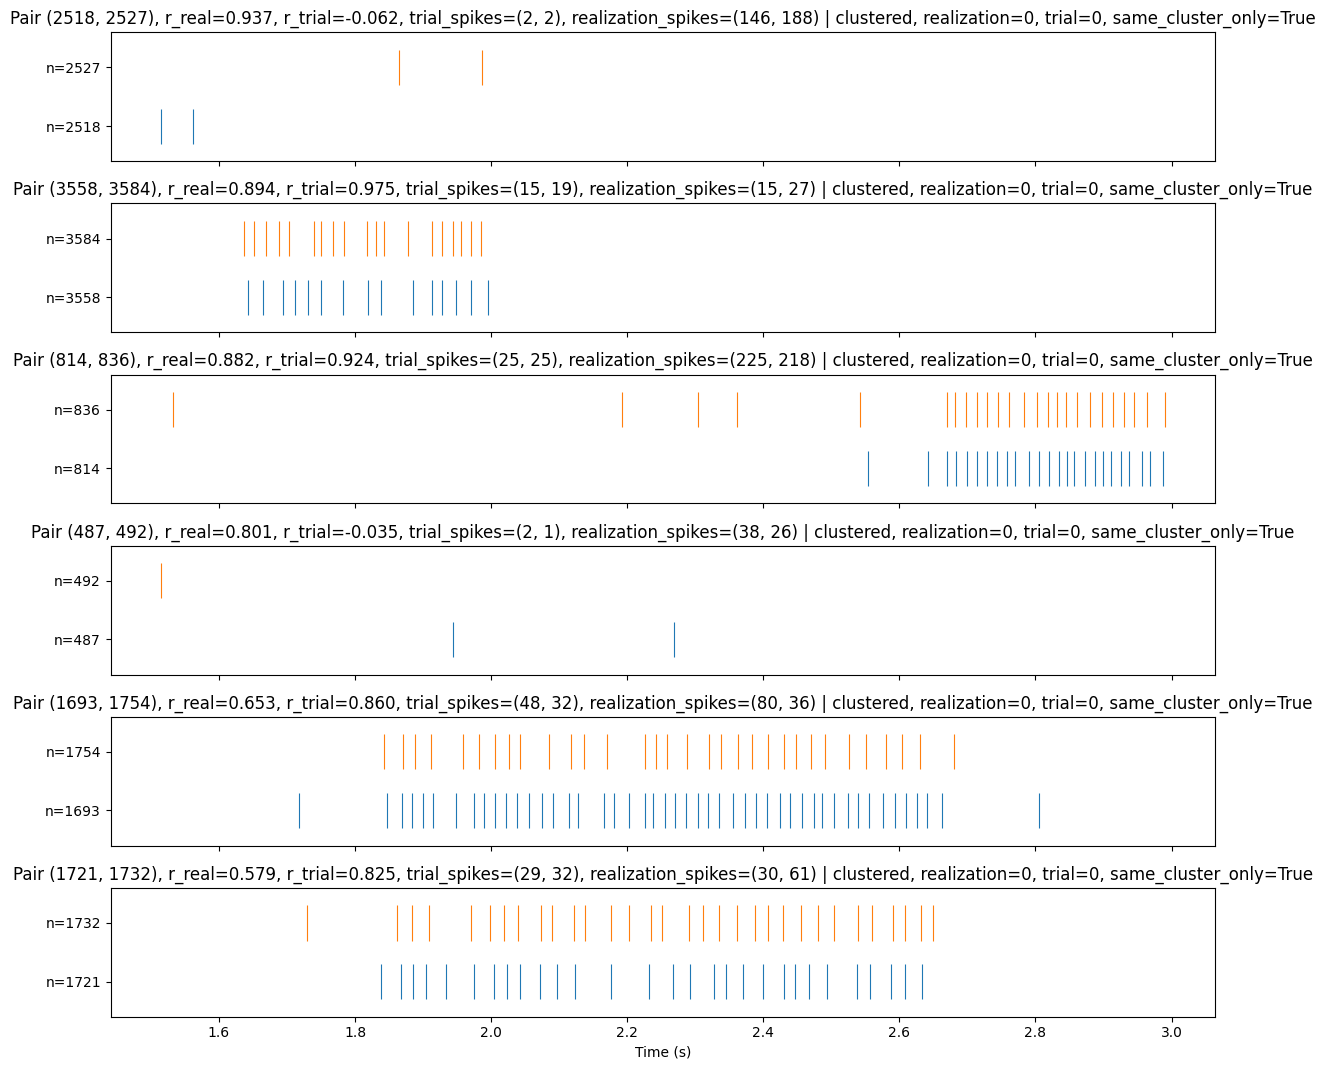

In [61]:
def plot_high_corr_pair_rasters(
    spike_data,
    network_type="clustered",
    realization=0,
    trial=0,
    corr_window=50*ms,
    corr_step=25*ms,
    same_cluster_only=False,
    n_pairs=6,
    threshold=0.4,
    seed=1,
):
    """Plot rasters for a sample of high-correlation neuron pairs.

    Uses the same realization-level correlation logic as compute_correlation_coefficients,
    including active-neuron filtering (neurons with zero spikes in the analysis window
    across the realization are excluded).

    Additional plotting filter:
    - for the selected trial raster, pairs are kept only if BOTH neurons have at least
      one spike in that trial's analysis window.
    """
    params = spike_data.model_params
    cluster_params = spike_data.cluster_params

    n_e = params.N_E
    timerange = (params.analysis_start_t, params.analysis_start_t + params.analysis_window_t)
    start_t_float = float(params.analysis_start_t)
    end_t_float = float(params.analysis_start_t + params.analysis_window_t)

    spikes_list = spike_data.clustered if network_type == "clustered" else spike_data.uniform
    trial_spikes_realization = spikes_list[realization]

    use_same_cluster = same_cluster_only and cluster_params.enabled
    cluster_size = cluster_params.cluster_size if use_same_cluster else None

    coeffs, pair_i, pair_j = _get_realization_pair_coefficients(
        trial_spikes_realization,
        n_e,
        corr_window,
        corr_step,
        timerange,
        start_t_float,
        end_t_float,
        same_cluster_only=use_same_cluster,
        cluster_size=cluster_size,
        return_pairs=True,
    )

    if coeffs.size == 0:
        print("No valid pairs found for this realization (after active-neuron filtering).")
        return np.array([], dtype=np.int32), coeffs, (pair_i, pair_j)

    # Trial-specific activity filter for raster plotting
    spike_times_trial, spike_ids_trial = spikes_list[realization][trial]
    spike_times_trial = np.asarray(spike_times_trial, dtype=float)
    spike_ids_trial = np.asarray(spike_ids_trial, dtype=np.int32)

    in_range_trial = (spike_times_trial >= start_t_float) & (spike_times_trial <= end_t_float)
    spike_times_trial = spike_times_trial[in_range_trial]
    spike_ids_trial = spike_ids_trial[in_range_trial]

    trial_counts = np.bincount(spike_ids_trial, minlength=n_e)
    trial_pair_active = (trial_counts[pair_i] > 0) & (trial_counts[pair_j] > 0)

    active_idx = np.where(trial_pair_active)[0]
    if active_idx.size == 0:
        print("No pairs have spikes from BOTH neurons in the selected trial analysis window.")
        return np.array([], dtype=np.int32), coeffs, (pair_i, pair_j)

    rng = np.random.default_rng(seed)
    high_idx = active_idx[coeffs[active_idx] >= threshold]

    if len(high_idx) == 0:
        sorted_active = active_idx[np.argsort(coeffs[active_idx])[::-1]]
        chosen = sorted_active[: min(n_pairs, len(sorted_active))]
        print(
            f"No trial-active pairs found above threshold r >= {threshold:.2f}; "
            f"showing top trial-active pairs instead."
        )
    else:
        n_select = min(n_pairs, len(high_idx))
        chosen = rng.choice(high_idx, size=n_select, replace=False)
        chosen = chosen[np.argsort(coeffs[chosen])[::-1]]
        print(
            f"Found {len(high_idx)} trial-active pairs above threshold r >= {threshold:.2f}; "
            f"plotting {len(chosen)} sampled pairs."
        )

    print(f"Filtered out {np.sum(~trial_pair_active)} pairs because at least one neuron had 0 spikes in plotted trial window.")
    print("Note: displayed r is realization-level (averaged across all trials in this realization).")
    print("A pair can have high realization-level r even if spikes are sparse/non-overlapping in the plotted trial.")

    realization_counts = np.zeros(n_e, dtype=np.int64)
    for times_r, ids_r in trial_spikes_realization:
        times_r = np.asarray(times_r, dtype=float)
        ids_r = np.asarray(ids_r, dtype=np.int32)
        in_range_r = (times_r >= start_t_float) & (times_r <= end_t_float)
        if np.any(in_range_r):
            realization_counts += np.bincount(ids_r[in_range_r], minlength=n_e)

    trial_window_counts = _window_spikes_all_neurons(
        spike_times_trial,
        spike_ids_trial,
        n_e,
        corr_window,
        corr_step,
        timerange,
    )

    fig, axes = plt.subplots(len(chosen), 1, figsize=(12, 1.8 * len(chosen)), sharex=True)
    if len(chosen) == 1:
        axes = [axes]

    for ax, idx in zip(axes, chosen):
        neuron_i, neuron_j = int(pair_i[idx]), int(pair_j[idx])
        r_ij = coeffs[idx]
        count_i = int(trial_counts[neuron_i])
        count_j = int(trial_counts[neuron_j])
        total_count_i = int(realization_counts[neuron_i])
        total_count_j = int(realization_counts[neuron_j])
        x_i_trial = trial_window_counts[neuron_i].astype(np.float64)
        x_j_trial = trial_window_counts[neuron_j].astype(np.float64)
        var_i_trial = np.var(x_i_trial, ddof=1)
        var_j_trial = np.var(x_j_trial, ddof=1)
        if var_i_trial > 0 and var_j_trial > 0:
            cov_trial = np.cov(x_i_trial, x_j_trial, bias=False)[0, 1]
            r_trial = cov_trial / np.sqrt(var_i_trial * var_j_trial)
            r_trial_str = f"{r_trial:.3f}"
        else:
            r_trial_str = "nan"

        t_i = spike_times_trial[spike_ids_trial == neuron_i]
        t_j = spike_times_trial[spike_ids_trial == neuron_j]

        ax.vlines(t_i, 0.7, 1.3, color="tab:blue", linewidth=0.8)
        ax.vlines(t_j, 1.7, 2.3, color="tab:orange", linewidth=0.8)
        ax.set_yticks([1, 2])
        ax.set_yticklabels([f"n={neuron_i}", f"n={neuron_j}"])
        ax.set_ylim(0.4, 2.6)
        ax.set_title(
            f"Pair ({neuron_i}, {neuron_j}), r_real={r_ij:.3f}, r_trial={r_trial_str}, "
            f"trial_spikes=({count_i}, {count_j}), realization_spikes=({total_count_i}, {total_count_j}) | "
            f"{network_type}, realization={realization}, trial={trial}, "
            f"same_cluster_only={use_same_cluster}"
        )

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

    return chosen, coeffs, (pair_i, pair_j)


# Example usage:
chosen_pairs, coeffs, pair_index_arrays = plot_high_corr_pair_rasters(
    spike_data,
    network_type="clustered",
    realization=0,
    trial=0,
    same_cluster_only=True,
    n_pairs=6,
    threshold=0.5,
)


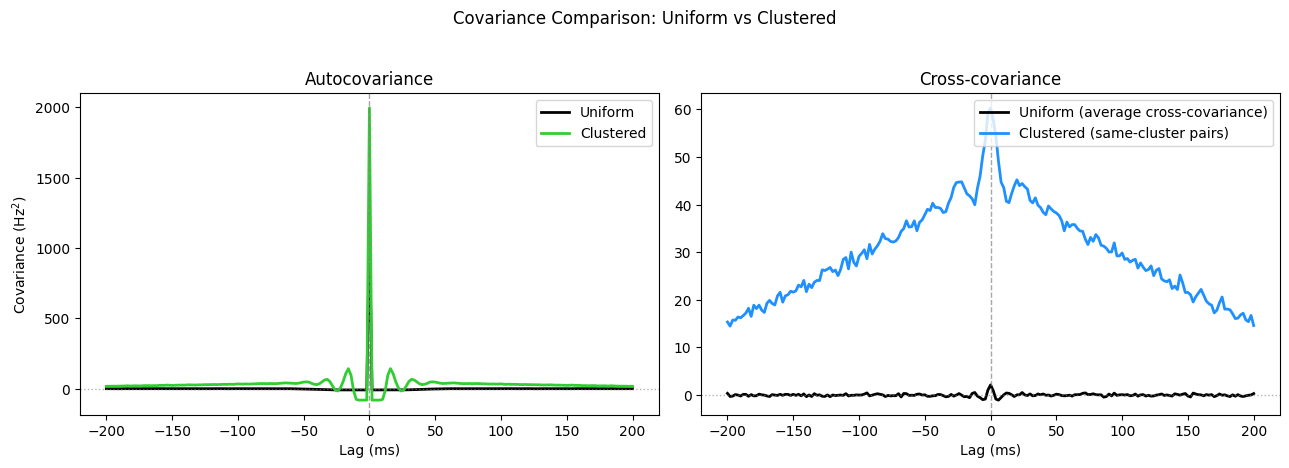

In [52]:
def _validate_covariance_curve_shapes(lags_ms, *curves):
    lags_ms = np.asarray(lags_ms)
    if lags_ms.ndim != 1:
        raise ValueError(f"lags_ms must be 1D, got shape {lags_ms.shape}.")

    for name, curve in curves:
        arr = np.asarray(curve)
        if arr.shape != lags_ms.shape:
            raise ValueError(
                f"{name} must have shape {lags_ms.shape}, got {arr.shape}."
            )


def plot_covariance_comparison(
    lags_ms,
    uniform_auto,
    clustered_auto,
    uniform_cross,
    clustered_cross,
    normalize_by_mean_rate=False,
    axes=None,
    title=None,
):
    """
    Plot autocovariance and cross-covariance comparisons.

    Cross-covariance convention in this plot:
      - uniform_cross: average cross-covariance in the uniform network (all sampled pairs)
      - clustered_cross: cross-covariance for same-cluster pairs in the clustered network
    """
    _validate_covariance_curve_shapes(
        lags_ms,
        ("uniform_auto", uniform_auto),
        ("clustered_auto", clustered_auto),
        ("uniform_cross", uniform_cross),
        ("clustered_cross", clustered_cross),
    )

    lags_ms = np.asarray(lags_ms)
    uniform_auto = np.asarray(uniform_auto)
    clustered_auto = np.asarray(clustered_auto)
    uniform_cross = np.asarray(uniform_cross)
    clustered_cross = np.asarray(clustered_cross)

    created_fig = False
    if axes is None:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
        created_fig = True
    else:
        if len(axes) != 2:
            raise ValueError("axes must contain exactly 2 Axes objects.")
        fig = axes[0].figure

    auto_ax, cross_ax = axes

    # Autocovariance panel
    auto_ax.plot(lags_ms, uniform_auto, color="black", linewidth=2, label="Uniform")
    auto_ax.plot(lags_ms, clustered_auto, color="limegreen", linewidth=2, label="Clustered")
    auto_ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
    auto_ax.axhline(0, color="gray", linestyle=":", linewidth=1, alpha=0.6)
    auto_ax.set_xlabel("Lag (ms)")
    auto_ax.set_ylabel(
        "Covariance / mean rate" if normalize_by_mean_rate else "Covariance (Hz$^2$)"
    )
    auto_ax.set_title("Autocovariance")
    auto_ax.legend()

    # Cross-covariance panel
    cross_ax.plot(
        lags_ms,
        uniform_cross,
        color="black",
        linewidth=2,
        label="Uniform (average cross-covariance)",
    )
    cross_ax.plot(
        lags_ms,
        clustered_cross,
        color="dodgerblue",
        linewidth=2,
        label="Clustered (same-cluster pairs)",
    )
    cross_ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
    cross_ax.axhline(0, color="gray", linestyle=":", linewidth=1, alpha=0.6)
    cross_ax.set_xlabel("Lag (ms)")
    cross_ax.set_title("Cross-covariance")
    cross_ax.legend()

    if title is None:
        title = "Covariance Comparison: Uniform vs Clustered"
    fig.suptitle(title, y=1.03)

    if created_fig:
        plt.tight_layout()

    return fig, axes


# Compute covariance curves directly from SpikeData in notebook context
# clustered_within_cluster_pairs=True ensures clustered_cross is same-cluster cross-covariance.
lags_ms, uniform_auto, uniform_cross, clustered_auto, clustered_cross = compute_covariance_uniform_vs_clustered_from_spike_data(
    spike_data,
    bin_size_ms=2,
    max_lag_ms=200,
    max_pairs=2000,
    seed=0,
    normalize_by_mean_rate=False,
    clustered_within_cluster_pairs=True,
)

fig, axes = plot_covariance_comparison(
    lags_ms,
    uniform_auto,
    clustered_auto,
    uniform_cross,
    clustered_cross,
    normalize_by_mean_rate=False,
)
plt.show()

